# Проект: Линейные модели в машинном обучении

## Задание
*Описание проекта*
*Вы работаете в IT-компании, которая выполняет на заказ проекты по машинному обучению. К вам обратился фермер, владелец молочного хозяйства «Вольный луг». Он хочет купить бурёнок, чтобы расширить поголовье стада коров. Для этого он заключил выгодный контракт с ассоциацией пастбищ «ЭкоФерма».*
*Условия позволяют фермеру очень тщательно отобрать коров. Он определяет качество молока по строгой методике, и при этом ему нужно выполнять свой план развития молочного хозяйства. Фермер хочет, чтобы каждая бурёнка давала не менее 6000 килограммов молока в год, а её надой был вкусным — строго по его критериям, ничуть не хуже. А продавцы и технологи так и норовят приукрасить своих коровок!*
*Поэтому он просит вас разработать модель машинного обучения, которая поможет ему управлять рисками и принимать объективное решение о покупке. «ЭкоФерма» готова предоставить подробные данные о своих коровах.*

**Вам нужно создать две прогнозные модели для отбора бурёнок в поголовье,**
- 	**Первая будет прогнозировать возможный удой коровы (целевой признак Удой);**
- 	**Вторая — рассчитывать вероятность получить вкусное молоко от коровы (целевой признак Вкус молока).**

**С помощью модели нужно отобрать коров по двум критериям,**
- **средний удой за год — не менее 6000 килограммов;**
- **молоко должно быть вкусным.**


In [1413]:
import pandas as pd
import os
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error, 
                             accuracy_score)
from math import sqrt

from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

from scipy import stats
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, confusion_matrix

вспомогательные функции,

In [1414]:
def correct_path (csv_name):
    if not os.path.exists(csv_name):
        return '/datasets/' + csv_name
    return csv_name

def check_na (data):
    for (field_name, field_content) in data.items():
        display (f"amount of NaN in {field_name} is {data[field_name].isna().sum()}, \
                 {(data[field_name].isna().sum() / len(data) * 100).astype('int')}%")

def rename_fields (data, features_names):
    for f in features_names:
        data = data.rename(columns={f[0]:f[1]})
    return data

def draw_numerical_stats(data, xlabel, ylabel, bins=50):
    display (f"********** Следующий признак: {xlabel}")
    fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(9, 4))
    axs[0].boxplot(data, vert=False);
    axs[1].hist(data, bins=bins);
    axs[1].set_xlabel(xlabel)
    axs[1].set_ylabel(ylabel)
    display(data.describe())
    plt.show();

def draw_categorial_stats (data, title):
    display (f"********** Следующий признак: {title}")
    data.value_counts().plot(title=title, kind='pie', autopct=lambda x: f"{x:.0f}%");
    plt.show();


## Загрузка данных

*Шаг 1. Загрузите и изучите данные*
1.	*Загрузите данные в датафреймы pandas. Файлы можно скачать по ссылкам в описании, они даже доступны через пути*
2.	*Изучите данные. Определите, соответствуют ли они описанию задачи и изученным в прошлых спринтах стандартам оформления данных. При необходимости переименуйте столбцы.*

In [1415]:
#ferma_main = pd.read_csv(correct_path('ferma_main.csv'))
ferma_main = pd.read_csv(correct_path('ferma_main.csv'), sep=';', decimal = ',')
display(ferma_main.info())
display(ferma_main.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 12 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     634 non-null    int64  
 1   Удой, кг                               634 non-null    int64  
 2   ЭКЕ (Энергетическая кормовая единица)  634 non-null    float64
 3   Сырой протеин, г                       634 non-null    int64  
 4   СПО (Сахаро-протеиновое соотношение)   634 non-null    float64
 5   Порода                                 634 non-null    object 
 6   Тип пастбища                           634 non-null    object 
 7   порода папы_быка                       634 non-null    object 
 8   Жирность,%                             634 non-null    float64
 9   Белок,%                                634 non-null    float64
 10  Вкус молока                            634 non-null    object 
 11  Возрас

None

,id,"Удой, кг",ЭКЕ (Энергетическая кормовая единица),"Сырой протеин, г",СПО (Сахаро-протеиновое соотношение),Порода,Тип пастбища,порода папы_быка,"Жирность,%","Белок,%",Вкус молока,Возраст
0,1,5863,14.2,1743,0.890,Вис Бик Айдиал,Равнинное,Айдиал,3.58,3.076,вкусно,более_2_лет
1,2,5529,12.8,2138,0.890,Вис Бик Айдиал,Равнинные,Соверин,3.54,3.079,вкусно,менее_2_лет
2,3,5810,14.0,1854,0.885,РефлешнСоверинг,Холмистое,Соверин,3.59,3.074,не вкусно,более_2_лет
3,4,5895,12.4,2012,0.885,РефлешнСоверинг,Холмистое,Айдиал,3.40,3.075,не вкусно,более_2_лет
4,5,5302,12.8,1675,0.885,Вис Бик Айдиал,Равнинные,Соверин,3.73,3.073,вкусно,менее_2_лет


In [1416]:
ferma_dad = pd.read_csv(correct_path('ferma_dad.csv'), sep=';')
display(ferma_dad.info())
display(ferma_dad.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        629 non-null    int64 
 1   Имя Папы  629 non-null    object
dtypes: int64(1), object(1)
memory usage: 10.0+ KB


None

,id,Имя Папы
0,1,Буйный
1,2,Соловчик
2,3,Барин
3,4,Буйный
4,5,Барин


In [1417]:
cow_buy = pd.read_csv(correct_path('cow_buy.csv'), sep=';', decimal = ',')
display(cow_buy.info())
display(cow_buy.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Порода                   20 non-null     object 
 1   Тип пастбища             20 non-null     object 
 2   порода папы_быка         20 non-null     object 
 3   Имя_папы                 20 non-null     object 
 4   Текущая_жирность,%       20 non-null     float64
 5   Текущий_уровень_белок,%  20 non-null     float64
 6   Возраст                  20 non-null     object 
dtypes: float64(2), object(5)
memory usage: 1.2+ KB


None

,Порода,Тип пастбища,порода папы_быка,Имя_папы,"Текущая_жирность,%","Текущий_уровень_белок,%",Возраст
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет


Имена заданы на русском языке, без стиля camel - переименуем:

In [1418]:
ferma_main_num_features=[ \
            ['Удой, кг', 'yield_kg'],
            ['ЭКЕ (Энергетическая кормовая единица)', 'energy_feed_unit'],
            ['Сырой протеин, г', 'crude_protein_g'],
            ['СПО (Сахаро-протеиновое соотношение)', 'sugar_protein_ratio'],
            ['Жирность,%', 'fat_percent'],
            ['Белок,%', 'protein_percent']]

ferma_main_cat_features=[ \
            ['Порода', 'breed'],
            ['Тип пастбища', 'pasture_type'],
            ['порода папы_быка', 'father_breed'],
            ['Вкус молока', 'taste_of_milk'],
            ['Возраст', 'age']]

ferma_main = rename_fields (ferma_main, ferma_main_num_features)
ferma_main = rename_fields (ferma_main, ferma_main_cat_features)

In [1419]:
ferma_main.info()
ferma_main.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   634 non-null    int64  
 1   yield_kg             634 non-null    int64  
 2   energy_feed_unit     634 non-null    float64
 3   crude_protein_g      634 non-null    int64  
 4   sugar_protein_ratio  634 non-null    float64
 5   breed                634 non-null    object 
 6   pasture_type         634 non-null    object 
 7   father_breed         634 non-null    object 
 8   fat_percent          634 non-null    float64
 9   protein_percent      634 non-null    float64
 10  taste_of_milk        634 non-null    object 
 11  age                  634 non-null    object 
dtypes: float64(4), int64(3), object(5)
memory usage: 59.6+ KB


,id,yield_kg,energy_feed_unit,crude_protein_g,sugar_protein_ratio,breed,pasture_type,father_breed,fat_percent,protein_percent,taste_of_milk,age
0,1,5863,14.2,1743,0.890,Вис Бик Айдиал,Равнинное,Айдиал,3.58,3.076,вкусно,более_2_лет
1,2,5529,12.8,2138,0.890,Вис Бик Айдиал,Равнинные,Соверин,3.54,3.079,вкусно,менее_2_лет
2,3,5810,14.0,1854,0.885,РефлешнСоверинг,Холмистое,Соверин,3.59,3.074,не вкусно,более_2_лет
3,4,5895,12.4,2012,0.885,РефлешнСоверинг,Холмистое,Айдиал,3.40,3.075,не вкусно,более_2_лет
4,5,5302,12.8,1675,0.885,Вис Бик Айдиал,Равнинные,Соверин,3.73,3.073,вкусно,менее_2_лет


In [1420]:
ferma_dad = ferma_dad.rename( columns={'Имя Папы': 'father_name'}) 

In [1421]:
ferma_dad.info()
ferma_dad.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           629 non-null    int64 
 1   father_name  629 non-null    object
dtypes: int64(1), object(1)
memory usage: 10.0+ KB


,id,father_name
0,1,Буйный
1,2,Соловчик
2,3,Барин
3,4,Буйный
4,5,Барин


In [1422]:
cow_buy_num_features=[ \
             ['Текущая_жирность,%', 'fat_percent'],
             ['Текущий_уровень_белок,%', 'protein_percent']]

cow_buy_cat_features=[ \
             ['Порода', 'breed'],
             ['Тип пастбища', 'pasture_type'],
             ['порода папы_быка', 'father_breed'],
             ['Имя_папы', 'father_name'],
             ['Возраст', 'age']]

cow_buy = rename_fields (cow_buy, cow_buy_num_features)

cow_buy = rename_fields (cow_buy, cow_buy_cat_features)


In [1423]:
cow_buy.info()
cow_buy.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   breed            20 non-null     object 
 1   pasture_type     20 non-null     object 
 2   father_breed     20 non-null     object 
 3   father_name      20 non-null     object 
 4   fat_percent      20 non-null     float64
 5   protein_percent  20 non-null     float64
 6   age              20 non-null     object 
dtypes: float64(2), object(5)
memory usage: 1.2+ KB


,breed,pasture_type,father_breed,father_name,fat_percent,protein_percent,age
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет


### Выводы

- разделитель таблицы ferma_main.csv пришлось переделать на ';'
- поля соответствуют описанию в задаче
- имена полей пришлось перевести и переименовать


##  Предобработка данных


*Проверьте данные на наличие пропусков и дубликатов. Узнайте, корректны ли типы данных у каждого признака. При необходимости устраните все проблемы с данными.*

Проверим пропуски:

In [1424]:
display(ferma_main.isna().sum())

id                     0
yield_kg               0
energy_feed_unit       0
crude_protein_g        0
sugar_protein_ratio    0
breed                  0
pasture_type           0
father_breed           0
fat_percent            0
protein_percent        0
taste_of_milk          0
age                    0
dtype: int64

In [1425]:
display(ferma_dad.isna().sum())

id             0
father_name    0
dtype: int64

In [1426]:
display(cow_buy.isna().sum())

breed              0
pasture_type       0
father_breed       0
father_name        0
fat_percent        0
protein_percent    0
age                0
dtype: int64

<- пропусков нет.

Проверим и исправим дубликаты:

In [1427]:
ferma_main.duplicated().sum()

5

In [1428]:
ferma_main = ferma_main.drop_duplicates().reset_index(drop=True)

In [1429]:
ferma_dad.duplicated().sum()

0

In [1430]:
cow_buy.duplicated().sum()

4

In [1431]:
##cow_buy = cow_buy.drop_duplicates().reset_index(drop=True)

Поищем неявные дубликаты:

In [1432]:
ferma_main ['breed'].value_counts()

Вис Бик Айдиал     373
РефлешнСоверинг    256
Name: breed, dtype: int64

In [1433]:
cow_buy ['breed'].value_counts()

РефлешнСоверинг    11
Вис Бик Айдиал      9
Name: breed, dtype: int64

In [1434]:
ferma_main ['pasture_type'].value_counts()

Холмистое    351
Равнинное    253
Равнинные     25
Name: pasture_type, dtype: int64

In [1435]:
cow_buy ['pasture_type'].value_counts()

равнинное    11
холмистое     9
Name: pasture_type, dtype: int64

In [1436]:
ferma_main ['pasture_type'] = ferma_main ['pasture_type']\
    .replace("Равнинные","Равнинное")
cow_buy ['pasture_type'] = ferma_main ['pasture_type']\
    .replace("равнинное","Равнинное")
cow_buy ['pasture_type'] = ferma_main ['pasture_type']\
    .replace("холмистое","Холмистое")


In [1437]:
ferma_main ['father_breed'].value_counts()

Соверин    311
Айдиал     240
Айдиалл     78
Name: father_breed, dtype: int64

In [1438]:
cow_buy ['father_breed'].value_counts()

Соверин    12
Айдиал      8
Name: father_breed, dtype: int64

In [1439]:
ferma_main ['father_breed'] = ferma_main ['father_breed']\
    .replace("Айдиалл","Айдиал")

In [1440]:
ferma_main ['taste_of_milk'].value_counts()

вкусно       371
не вкусно    258
Name: taste_of_milk, dtype: int64

In [1441]:
ferma_main ['age'].value_counts()

более_2_лет    519
менее_2_лет    110
Name: age, dtype: int64

In [1442]:
cow_buy  ['age'].value_counts()

более_2_лет    15
менее_2_лет     5
Name: age, dtype: int64

In [1443]:
ferma_dad ['father_name'].value_counts()

Барин       240
Буйный      215
Соловчик    110
Геркулес     64
Name: father_name, dtype: int64

In [1444]:
cow_buy ['father_name'].value_counts()

Буйный      8
Геркулес    6
Барин       4
Соловчик    2
Name: father_name, dtype: int64

Исправим типы:

In [1445]:
ferma_main.info()
ferma_main.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   629 non-null    int64  
 1   yield_kg             629 non-null    int64  
 2   energy_feed_unit     629 non-null    float64
 3   crude_protein_g      629 non-null    int64  
 4   sugar_protein_ratio  629 non-null    float64
 5   breed                629 non-null    object 
 6   pasture_type         629 non-null    object 
 7   father_breed         629 non-null    object 
 8   fat_percent          629 non-null    float64
 9   protein_percent      629 non-null    float64
 10  taste_of_milk        629 non-null    object 
 11  age                  629 non-null    object 
dtypes: float64(4), int64(3), object(5)
memory usage: 59.1+ KB


,id,yield_kg,energy_feed_unit,crude_protein_g,sugar_protein_ratio,breed,pasture_type,father_breed,fat_percent,protein_percent,taste_of_milk,age
0,1,5863,14.2,1743,0.890,Вис Бик Айдиал,Равнинное,Айдиал,3.58,3.076,вкусно,более_2_лет
1,2,5529,12.8,2138,0.890,Вис Бик Айдиал,Равнинное,Соверин,3.54,3.079,вкусно,менее_2_лет
2,3,5810,14.0,1854,0.885,РефлешнСоверинг,Холмистое,Соверин,3.59,3.074,не вкусно,более_2_лет
3,4,5895,12.4,2012,0.885,РефлешнСоверинг,Холмистое,Айдиал,3.40,3.075,не вкусно,более_2_лет
4,5,5302,12.8,1675,0.885,Вис Бик Айдиал,Равнинное,Соверин,3.73,3.073,вкусно,менее_2_лет


In [1446]:
"""ferma_main['energy_feed_unit'] = ferma_main['energy_feed_unit']\
    .str.replace(',', '.').astype(float)
ferma_main['sugar_protein_ratio'] = ferma_main['sugar_protein_ratio']\
    .str.replace(',', '.').astype(float)
ferma_main['fat_percent'] = ferma_main['fat_percent']\
    .str.replace(',', '.').astype(float)
ferma_main['protein_percent'] = ferma_main['protein_percent']\
    .str.replace(',', '.').astype(float)
ferma_main.info()
ferma_main.head()"""

"ferma_main['energy_feed_unit'] = ferma_main['energy_feed_unit']    .str.replace(',', '.').astype(float)\nferma_main['sugar_protein_ratio'] = ferma_main['sugar_protein_ratio']    .str.replace(',', '.').astype(float)\nferma_main['fat_percent'] = ferma_main['fat_percent']    .str.replace(',', '.').astype(float)\nferma_main['protein_percent'] = ferma_main['protein_percent']    .str.replace(',', '.').astype(float)\nferma_main.info()\nferma_main.head()"

In [1447]:
ferma_dad.info()
ferma_dad.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           629 non-null    int64 
 1   father_name  629 non-null    object
dtypes: int64(1), object(1)
memory usage: 10.0+ KB


,id,father_name
0,1,Буйный
1,2,Соловчик
2,3,Барин
3,4,Буйный
4,5,Барин


<- ok

In [1448]:
cow_buy.info()
cow_buy.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   breed            20 non-null     object 
 1   pasture_type     20 non-null     object 
 2   father_breed     20 non-null     object 
 3   father_name      20 non-null     object 
 4   fat_percent      20 non-null     float64
 5   protein_percent  20 non-null     float64
 6   age              20 non-null     object 
dtypes: float64(2), object(5)
memory usage: 1.2+ KB


,breed,pasture_type,father_breed,father_name,fat_percent,protein_percent,age
0,Вис Бик Айдиал,Равнинное,Айдиал,Геркулес,3.58,3.076,более_2_лет
1,Вис Бик Айдиал,Равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет
2,РефлешнСоверинг,Холмистое,Соверин,Барин,3.59,3.074,более_2_лет
3,РефлешнСоверинг,Холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет
4,РефлешнСоверинг,Равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет


In [1449]:
"""cow_buy['fat_percent'] = cow_buy['fat_percent']\
    .str.replace(',', '.').astype(float)
cow_buy['protein_percent'] = cow_buy['protein_percent']\
    .str.replace(',', '.').astype(float)
cow_buy.info()
cow_buy.head()"""

"cow_buy['fat_percent'] = cow_buy['fat_percent']    .str.replace(',', '.').astype(float)\ncow_buy['protein_percent'] = cow_buy['protein_percent']    .str.replace(',', '.').astype(float)\ncow_buy.info()\ncow_buy.head()"

### Выводы
- исправлены типы с object на float
- удалены явные и исправлены неявные дубликаты

## Исследовательский анализ данных

1.	*Проведите статистический анализ всех признаков.*
2.	*Постройте графики для каждого признака. Помните, что количественным и категориальным признакам подходят разные графики.*

### Рассмотрим числовые фичи таблицы ferma_main

'********** Следующий признак: Удой, кг'

count      629.000000
mean      6188.750397
std       1644.795489
min       5204.000000
25%       5751.000000
50%       6133.000000
75%       6501.000000
max      45616.000000
Name: yield_kg, dtype: float64

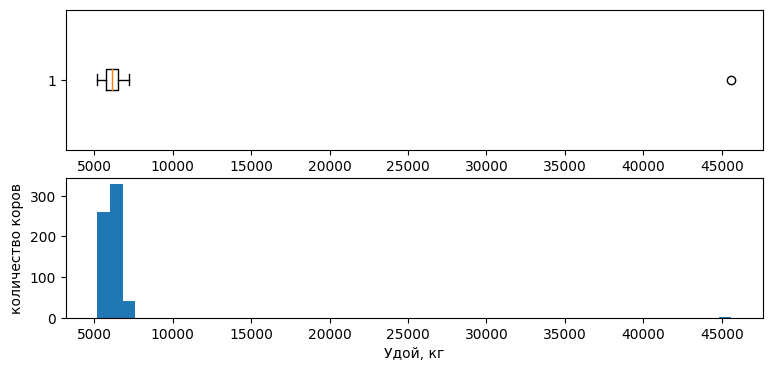

'********** Следующий признак: ЭКЕ (Энергетическая кормовая единица)'

count    629.000000
mean      14.543879
std        1.306408
min       10.900000
25%       13.500000
50%       14.700000
75%       15.600000
max       16.800000
Name: energy_feed_unit, dtype: float64

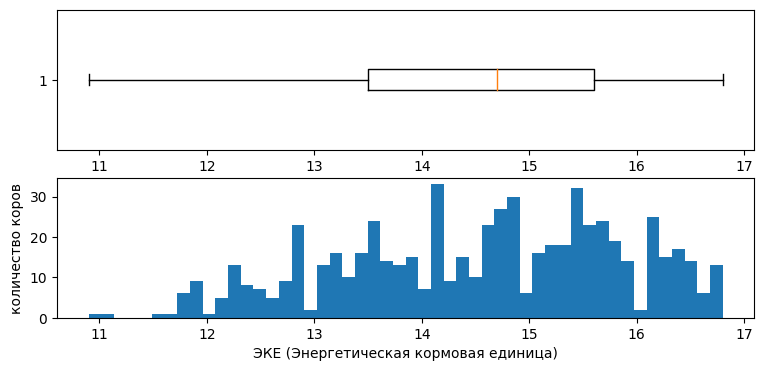

'********** Следующий признак: Сырой протеин, г'

count     629.000000
mean     1923.364070
std       182.956251
min      1660.000000
25%      1771.000000
50%      1888.000000
75%      2062.000000
max      2349.000000
Name: crude_protein_g, dtype: float64

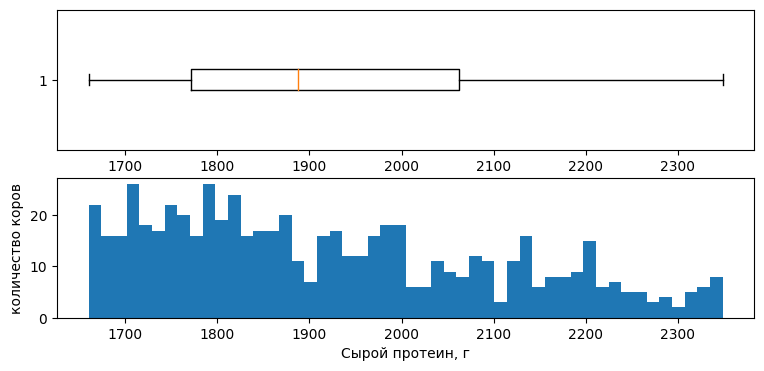

'********** Следующий признак: СПО (Сахаро-протеиновое соотношение)'

count    629.000000
mean       0.913116
std        0.032203
min        0.840000
25%        0.890000
50%        0.930000
75%        0.940000
max        0.960000
Name: sugar_protein_ratio, dtype: float64

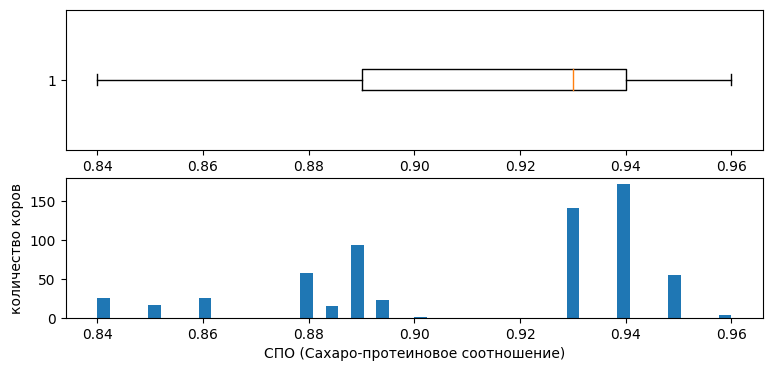

'********** Следующий признак: Жирность,%'

count    629.000000
mean       3.603657
std        0.168656
min        2.990000
25%        3.590000
50%        3.650000
75%        3.720000
max        3.750000
Name: fat_percent, dtype: float64

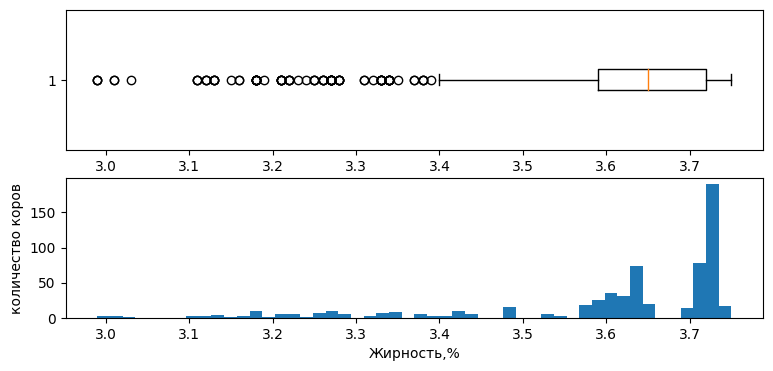

'********** Следующий признак: Белок,%'

count    629.000000
mean       3.075671
std        0.002549
min        3.069000
25%        3.074000
50%        3.076000
75%        3.077000
max        3.085000
Name: protein_percent, dtype: float64

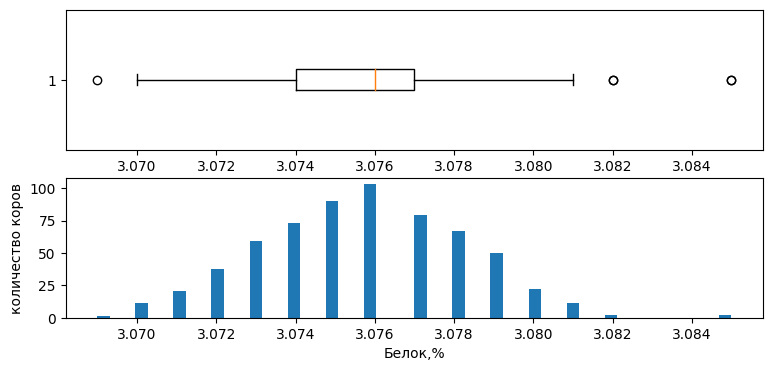

In [1450]:
for f in ferma_main_num_features:
    draw_numerical_stats (ferma_main[f[1]], xlabel=f[0],
                        ylabel='количество коров')

Изучим детальнее графики, вызвавшие вопросы (остальное будет описано в следующем разделе ).

<br/>
<div class="alert alert-info">
#2

уберём 3 выброса в белке и перепроверим график
</div>

'********** Следующий признак: белок, г'

count    624.000000
mean       3.075631
std        0.002464
min        3.070000
25%        3.074000
50%        3.076000
75%        3.077000
max        3.081000
Name: protein_percent, dtype: float64

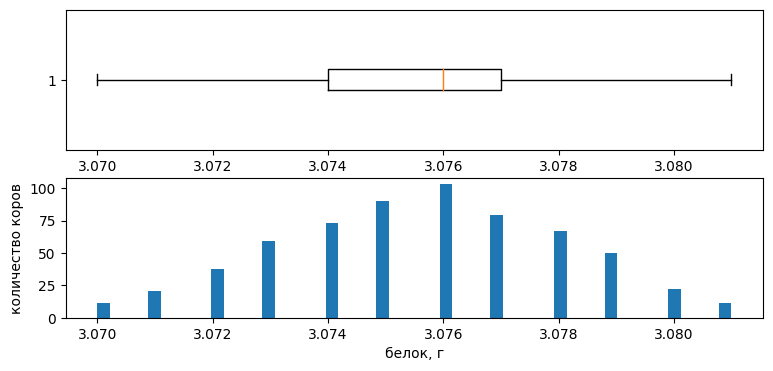

In [1451]:
ferma_main = ferma_main.drop(ferma_main[ferma_main['protein_percent'] < 3.07].index)
ferma_main = ferma_main.drop(ferma_main[ferma_main['protein_percent'] > 3.081].index)
draw_numerical_stats (ferma_main['protein_percent'], xlabel='белок, г',
                       ylabel='количество коров')

По **удою** виден выброс в 45616, при медианном значении 6133. Посмотрим, кто это такой:

In [1452]:
ferma_main.query('yield_kg > 40000')

,id,yield_kg,energy_feed_unit,crude_protein_g,sugar_protein_ratio,breed,pasture_type,father_breed,fat_percent,protein_percent,taste_of_milk,age
16,17,45616,11.5,1675,0.93,Вис Бик Айдиал,Холмистое,Айдиал,3.22,3.076,вкусно,более_2_лет


Пока сложно сказать, с чем связан выброс, вероятно это ошибка в данных - корова не может за один раз выдать 40 тонн молока. Можно было бы заменить выброс на медианное значение, но я принял решение в данном случае удалить эту корову.

In [1453]:
display(len(ferma_main))
ferma_main = ferma_main.drop( ferma_main[(ferma_main['yield_kg'] > 40000)].index )
display(len(ferma_main)) # проверим число строк

624

623

Посмотрим, что получилось.

'********** Следующий признак: удой, кг'

count     623.000000
mean     6127.232745
std       476.314531
min      5204.000000
25%      5748.500000
50%      6133.000000
75%      6501.000000
max      7222.000000
Name: yield_kg, dtype: float64

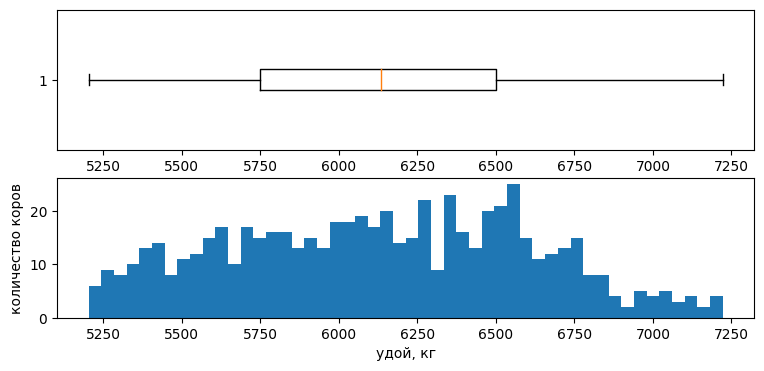

In [1454]:
draw_numerical_stats (ferma_main['yield_kg'], xlabel='удой, кг',
                       ylabel='количество коров')

<- другое дело, выбросов больше нет, перекосов тоже. Распределение стало больше похоже на нормальное.

Попробуем взглянуть чуть шире на **"СПО (Сахаро-протеиновое соотношение)'"**.

'********** Следующий признак: Сахаро-протеиновое соотношение'

count    623.000000
mean       0.913283
std        0.032150
min        0.840000
25%        0.890000
50%        0.930000
75%        0.940000
max        0.960000
Name: sugar_protein_ratio, dtype: float64

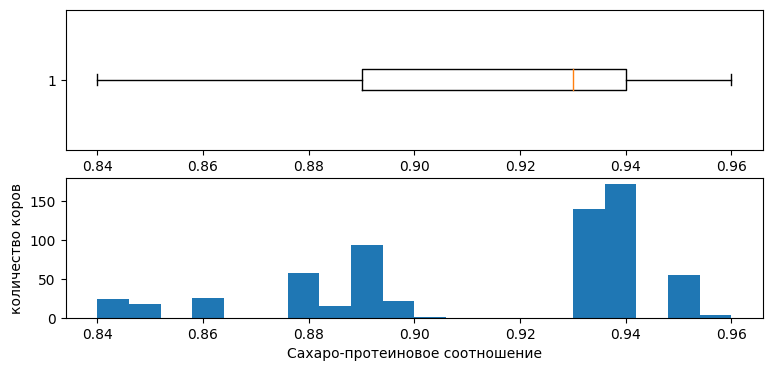

In [1455]:
draw_numerical_stats (ferma_main['sugar_protein_ratio'], xlabel='Сахаро-протеиновое соотношение',
                       ylabel='количество коров', bins=20)

<- всё равно данные сильно разрежены. ~~Сложно дать оценку распределению.~~

распределение не похоже на нормальное - возможно, это смесь распределений 

У **Жирности,%** - медиана также смещена в бОльшую сторону. Много выбросов с малыми значениями. Оценим шире:

'********** Следующий признак: Жирность,%'

count    623.000000
mean       3.604735
std        0.167712
min        2.990000
25%        3.590000
50%        3.650000
75%        3.720000
max        3.750000
Name: fat_percent, dtype: float64

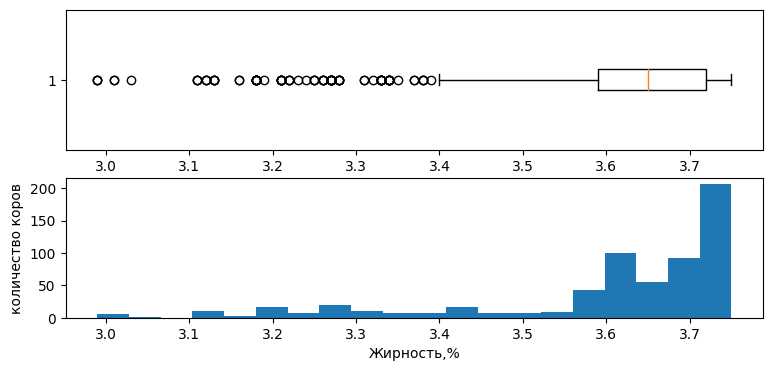

In [1456]:
draw_numerical_stats (ferma_main['fat_percent'], xlabel='Жирность,%',
                       ylabel='количество коров', bins=20)

<- много выбросов. Аргументированно их удалить не виду способа. Думаю, правильно оставить эти данные как есть. Есть коровы у которых малая жирность молока - информация о них может пригодится (например, как о неудачно взрощенных коровах, в случае, если жирность окажется важным фактором при выборе. Тогда можно будет выявить паттерны таких "плохих" кейсов, чтобы избегать их в будущем при выращивании коров).

### Рассмотрим категориальные фичи таблицы ferma_main:

'********** Следующий признак: Порода'

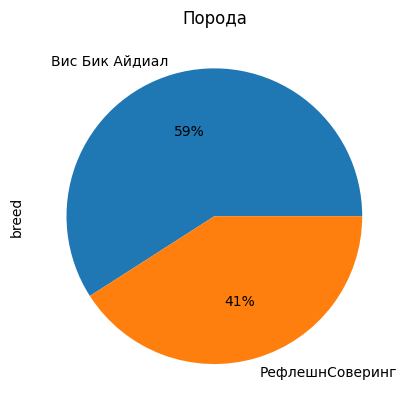

'********** Следующий признак: Тип пастбища'

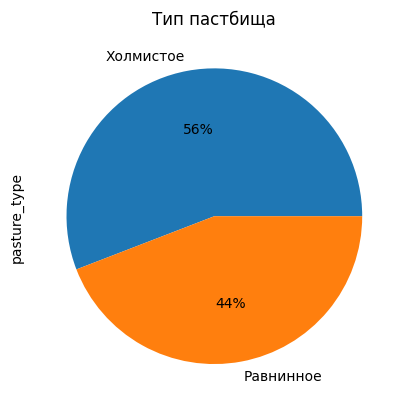

'********** Следующий признак: порода папы_быка'

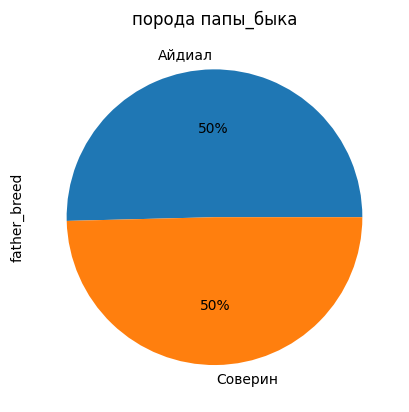

'********** Следующий признак: Вкус молока'

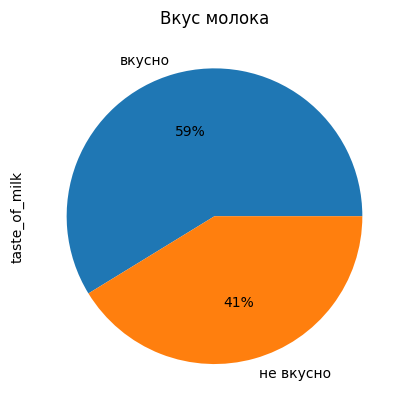

'********** Следующий признак: Возраст'

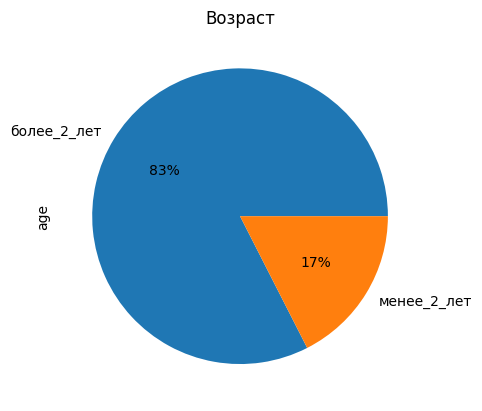

In [1457]:
for f in ferma_main_cat_features:
    draw_categorial_stats (ferma_main[f[1]], f[0])

### Рассмотрим таблицу с папами коров:

'********** Следующий признак: Имя Папы'

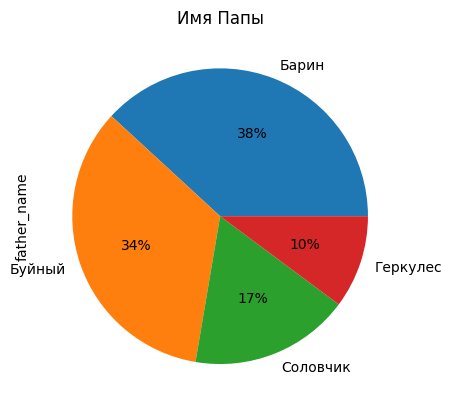

In [1458]:
draw_categorial_stats (ferma_dad['father_name'], 'Имя Папы')

### Рассмотрим числовые фичи таблицы cow_buy

'********** Следующий признак: Текущая_жирность,%'

count    20.000000
mean      3.577500
std       0.126818
min       3.340000
25%       3.510000
50%       3.590000
75%       3.650000
max       3.770000
Name: fat_percent, dtype: float64

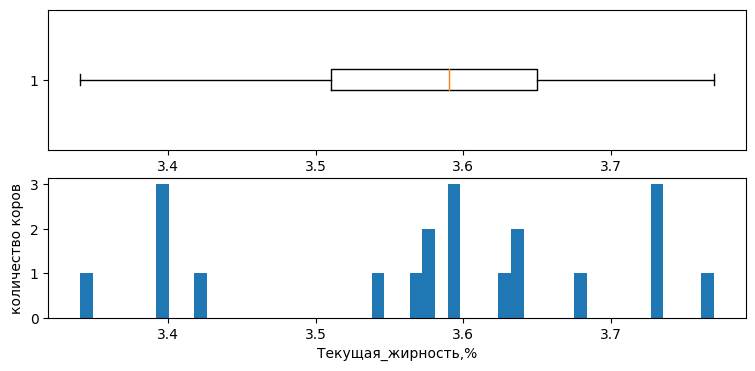

'********** Следующий признак: Текущий_уровень_белок,%'

count    20.000000
mean      3.069500
std       0.010339
min       3.046000
25%       3.064000
50%       3.074000
75%       3.076000
max       3.081000
Name: protein_percent, dtype: float64

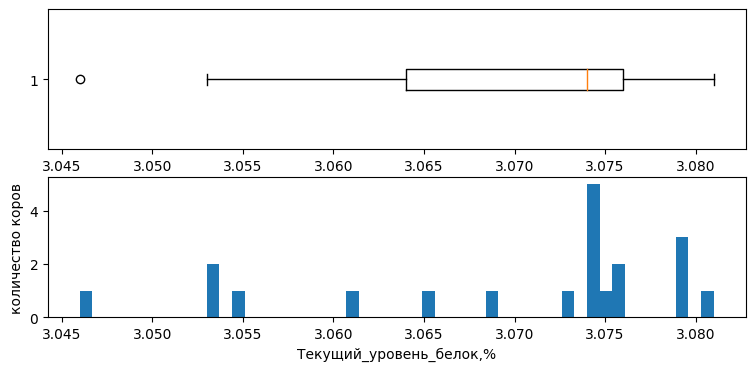

In [1459]:
for f in cow_buy_num_features:
    draw_numerical_stats (cow_buy[f[1]], xlabel=f[0],
                        ylabel='количество коров')

### Рассмотрим категориальные фичи таблицы cow_buy:

'********** Следующий признак: Порода'

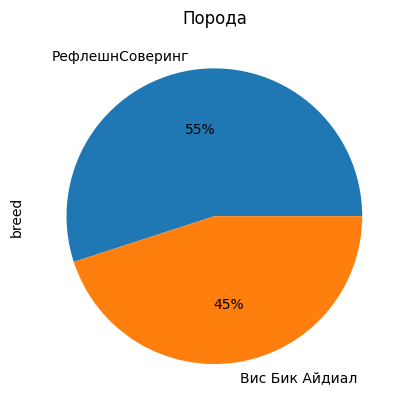

'********** Следующий признак: Тип пастбища'

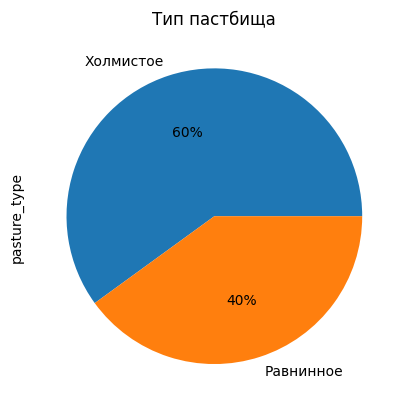

'********** Следующий признак: порода папы_быка'

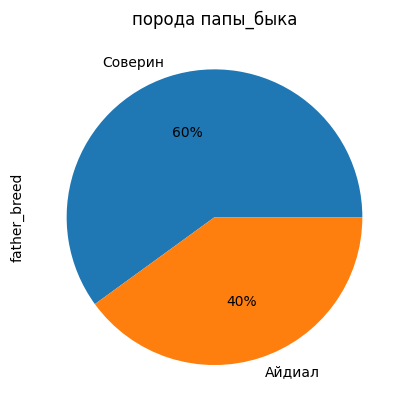

'********** Следующий признак: Имя_папы'

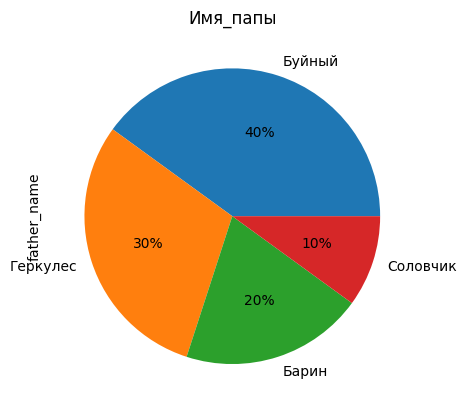

'********** Следующий признак: Возраст'

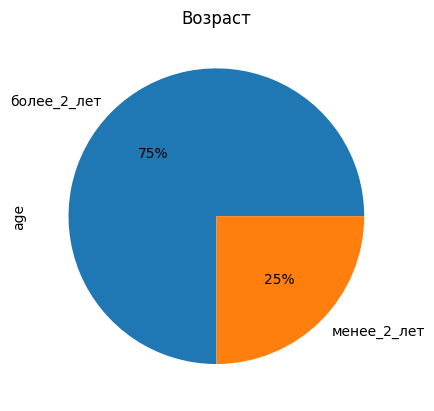

In [1460]:
for f in cow_buy_cat_features:
    draw_categorial_stats (cow_buy[f[1]], f[0])

Сравним графики по одним и тем же фичам у нашего клиента фермера (хозяина «Вольный луг») и у ЭкоФермы, где он собирается покупать коров.

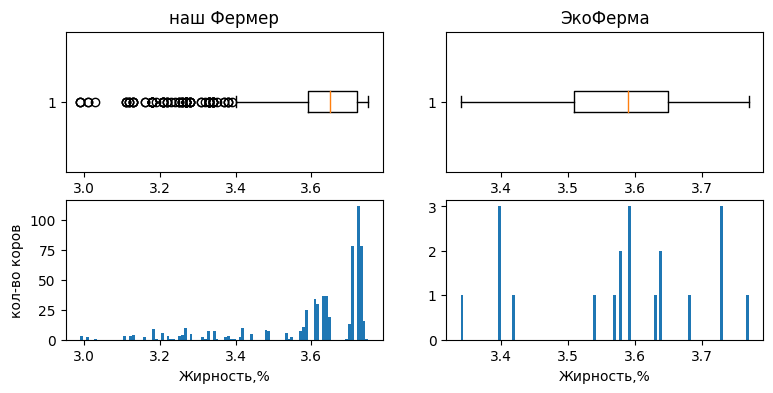

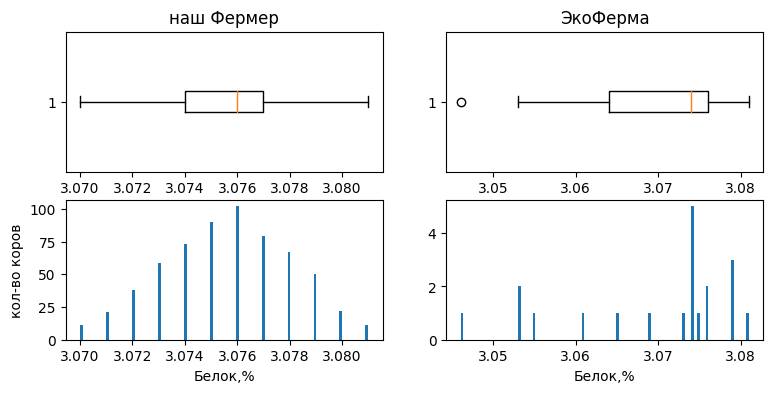

In [1461]:
cow_buy_num_features_df = pd.DataFrame(cow_buy_num_features, columns=['ru_name', 'en_name'])
ferma_main_num_features_df = pd.DataFrame(ferma_main_num_features, columns=['ru_name', 'en_name'])
dj = cow_buy_num_features_df.merge(ferma_main_num_features_df, on='en_name', how='inner')
dj = dj.reset_index()


for i, f in dj.iterrows():
    fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(9, 4))

    axs[0,0].boxplot(ferma_main[f['en_name']], vert=False);
    axs[1,0].hist(ferma_main[f['en_name']], bins=100);
    axs[0,0].set_title('наш Фермер')
    axs[1,0].set_xlabel(f['ru_name_y'])
    axs[1,0].set_ylabel("кол-во коров")

    axs[0,1].boxplot(cow_buy[f['en_name']], vert=False);
    axs[1,1].hist(cow_buy[f['en_name']], bins=100);
    axs[0,1].set_title('ЭкоФерма')
    axs[1,1].set_xlabel(f['ru_name_y'])
    plt.show();


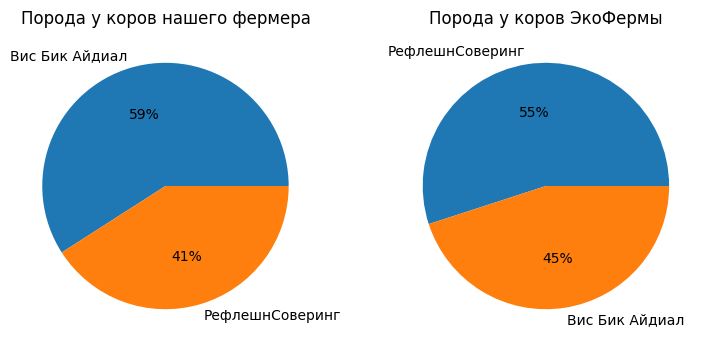

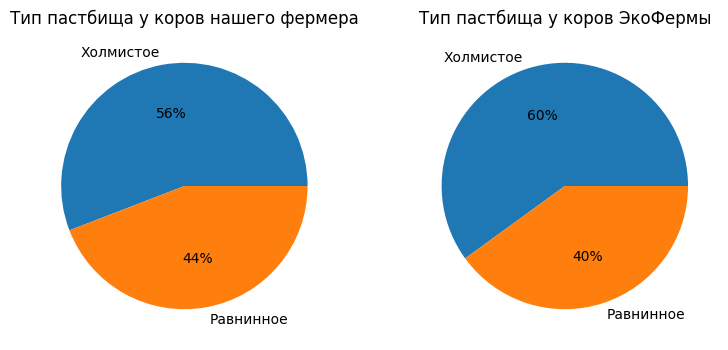

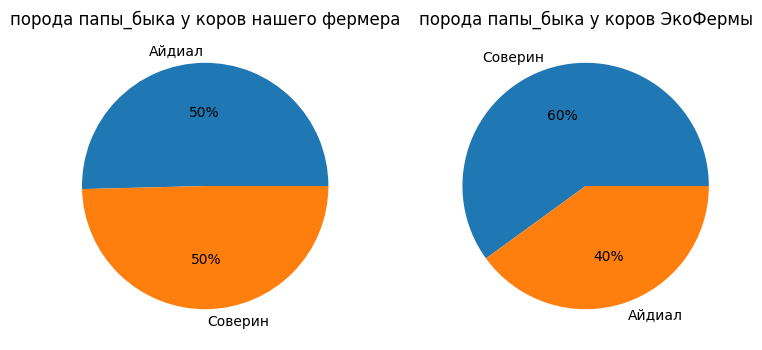

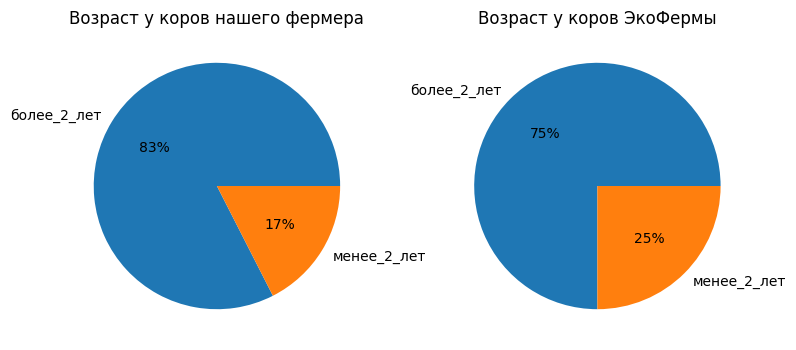

In [1462]:
cow_buy_cat_features_df = pd.DataFrame(cow_buy_cat_features, columns=['ru_name', 'en_name'])
ferma_main_cat_features_df = pd.DataFrame(ferma_main_cat_features, columns=['ru_name', 'en_name'])
dj = cow_buy_cat_features_df.merge(ferma_main_cat_features_df, on='en_name', how='inner')
dj = dj.reset_index()


for i, f in dj.iterrows():
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
    fmvc = ferma_main[f['en_name']].value_counts()
    axs[0].pie(fmvc, labels = fmvc.index, autopct=lambda x: f"{x:.0f}%");
    axs[0].set_title(f"{f['ru_name_y']} у коров нашего фермера")
    cbvc = cow_buy[f['en_name']].value_counts()
    axs[1].pie(cbvc, labels = cbvc.index, autopct=lambda x: f"{x:.0f}%");
    axs[1].set_title(f"{f['ru_name_y']} у коров ЭкоФермы")
    plt.show();


### Выводы
*3.	Сделайте выводы о данных:*
1. *напишите, заметили ли вы выбросы, необычное распределение количественных признаков или другие особенности;*
1. *расскажите, как вы планируете улучшить данные.*

Таблица ferma_main
- Удалена корова id=17 из-за выбросов по удою (40 тонн). распределение после этого стало похоже на нормальное.
- "ЭКЕ (Энергетическая кормовая единица)" - выбросов не видно, распределение похоже на нормальное, медана смещена в бОльшую сторону
- "Сырой протеин" - выбросов не видно. Распределение похоже выглядит нормальное со сдвигом в меньшую сторону. 
- "СПО (Сахаро-протеиновое соотношение)" - выбросов нет. Данные сильно разрежены. Медиана сильно сдвинута в бОльшую сторону.  Распределение оценить трудно.  Оснований как-либо корректировать его - не видно.
-  Жирность,%' - медиана сильно смещена в бОльшую сторону. Много выбросов. Определить распределение трудно - возможно, это сильно смещённое вправо нормальное распределение.
- Белок,% - распределение нормальное, медиана по центру, есть 3 выброса. При этом стандартное отклонение крайне мало. Поэтому выбросы, кажется, что можно оставить.
- всего 2 породы коров, большинство (59%) - Вис Бк Айдиал
- всего 2 типа пастбищ, большинство (56%) - Холмистое
- всего 2 породы папы_быка, распределены поровну
- всего 2 категории оценки вкусности молока: "вкусно" (59%) и и "не вкусно"
- всего 2 категории возраста коров "более 2 лет" (82%) и менее 2 лет

Таблица ferma_dad
- У коров всего 4 папы, лидер Барин (38%) и Буйный (34%)

Таблица cow_buy
- Жирность по медиане довольно близка к жирности коров нашего фермера (~3.6%). При этом у нашего фермера пики ближе к высоким значениям жирности, а у ЭкоФермы пики как на высоких, так и на низких значениях. Если наш фермер любит молоко пожирнее, то не факт, что его устроит вкус молока коров ЭкоФермы. Но изучим это позднее моделью, пока это только предположение. Распределение оценить сложно из-за разреженности данных.
- Распределение белка ЭкоФермы не похоже на нормальное (в отличи от молока нашего фермера). Медиана смещена в бОльшую сторону, выбросов нет.
- На ЭкоФерме те же 2 породы, что и у нашего фермера, 50/50%.
- Тип пастбищ - те же два, что и у фермера, но распределены также поровну.
- Пород пап коров - те же две, что и у нашего фермера, но на Экоферме больше (62%) коров от папы породы Соверин.
- На экоферме другой распределение пап. Лидирует Буйный с 44% (против 34% Буйного у нашего фермера). На втором месте Геркулес (с 31% против 10% Геркулеса у фермера). Барин же, лидировавший у Фермера (с 38%) на ЭкоФерме представлен лишь 12%.
    - Папы у коров сильно отличаются у фермера и на ЭкоФерме.
- На экоферме также 2 категории возрастов и также преимущественно коровы старше 2 лет (69% против 82% у фермера). 
    - Коровы на ЭкоФерме - помоложе, чем у фермера. Возможно, это хороший доп-фактор при покупке (если главные KPI выполнены).

Как улучшить распределение данных, и надо ли (кроме удаление одного выброса) - пока не понятно. Подскажите, пожалуйста, если что-то упускаю.

## Корреляционный анализ

*1. Изучите взаимосвязь между признаками: рассчитайте коэффициенты корреляции между всеми признаками.*

In [1464]:
!pip install phik
from phik import phik_matrix

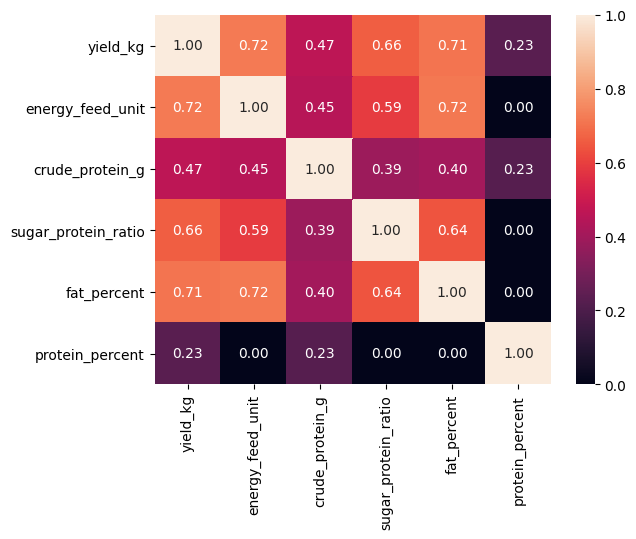

In [1465]:
c = ['yield_kg','energy_feed_unit','crude_protein_g','sugar_protein_ratio','fat_percent','protein_percent']
tmp = ferma_main[c]

sns.heatmap(tmp.phik_matrix(interval_cols=c), annot=True, fmt='.2f');

Выводы ниже.

*2.	Постройте диаграммы рассеяния scatterplot для признака Удой, кг и всех количественных признаков с учётом значения категориальных признаков. Пример: диаграмма рассеяния для Удой, кг и Сырой протеин, г, цвет точек диаграммы отображает признак Порода. Учитывайте, что виды связи в подгруппах могут различаться — например, для разных пород.*

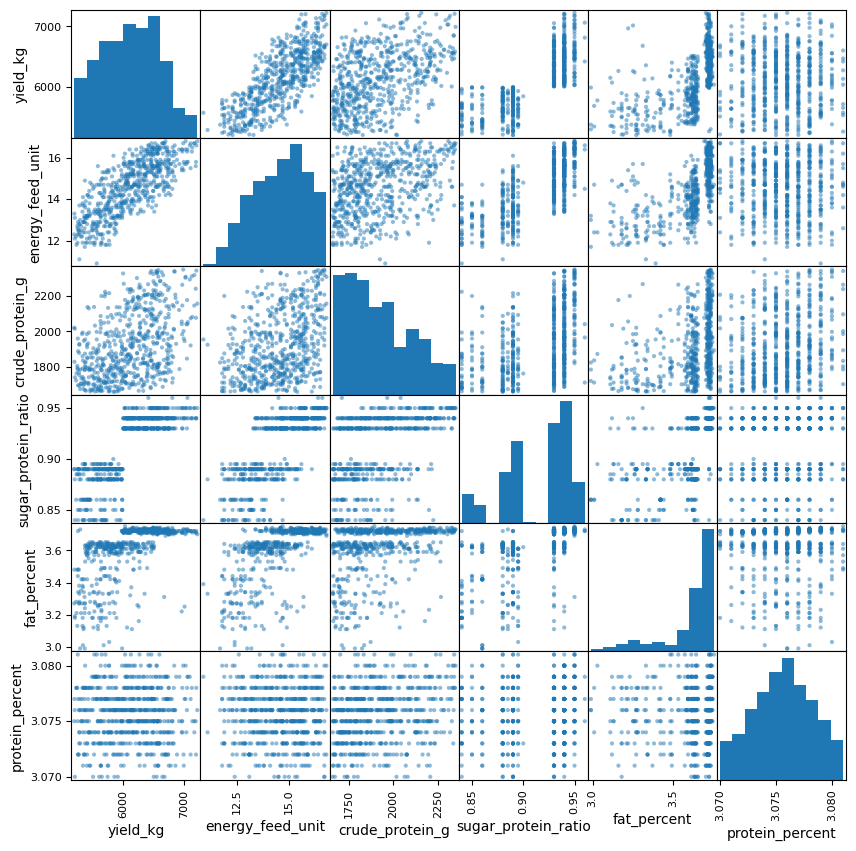

In [1466]:
ferma_main_cat = ferma_main[ferma_main_num_features_df['en_name']]
pd.plotting.scatter_matrix(ferma_main_cat, figsize=(10, 10));

Попробуем выяснить, проявляется ли корреляция для отдельных категориальных подгрупп.

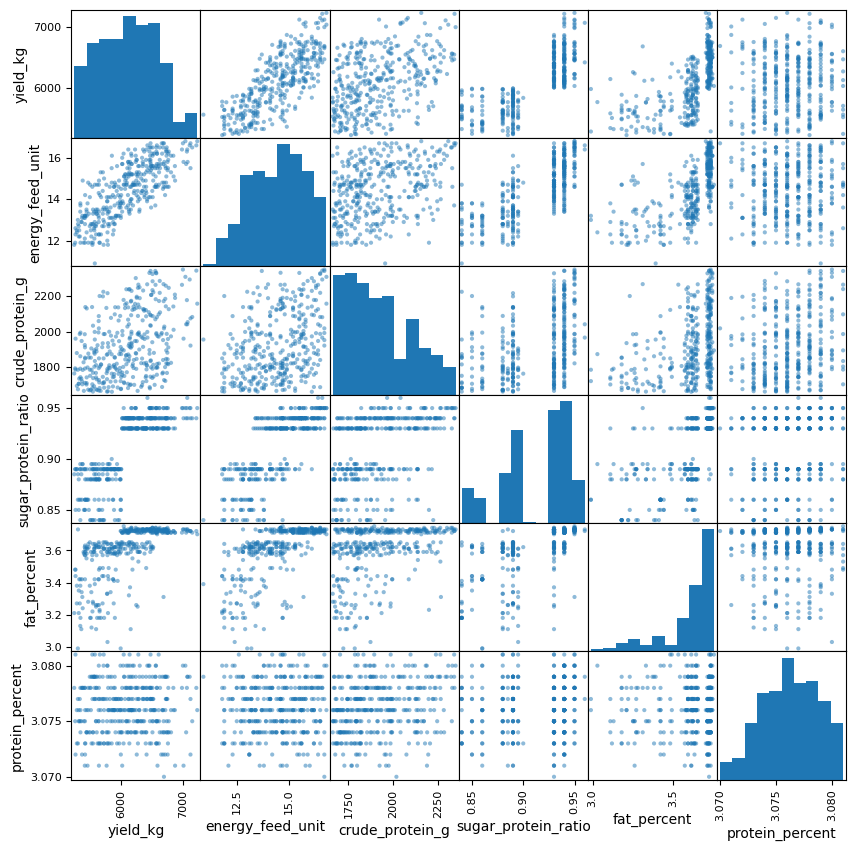

In [1467]:
ferma_main_cat = ferma_main.query('breed=="Вис Бик Айдиал"')[ferma_main_num_features_df['en_name']]
pd.plotting.scatter_matrix(ferma_main_cat, figsize=(10, 10));

<- разделение по породе не помогло

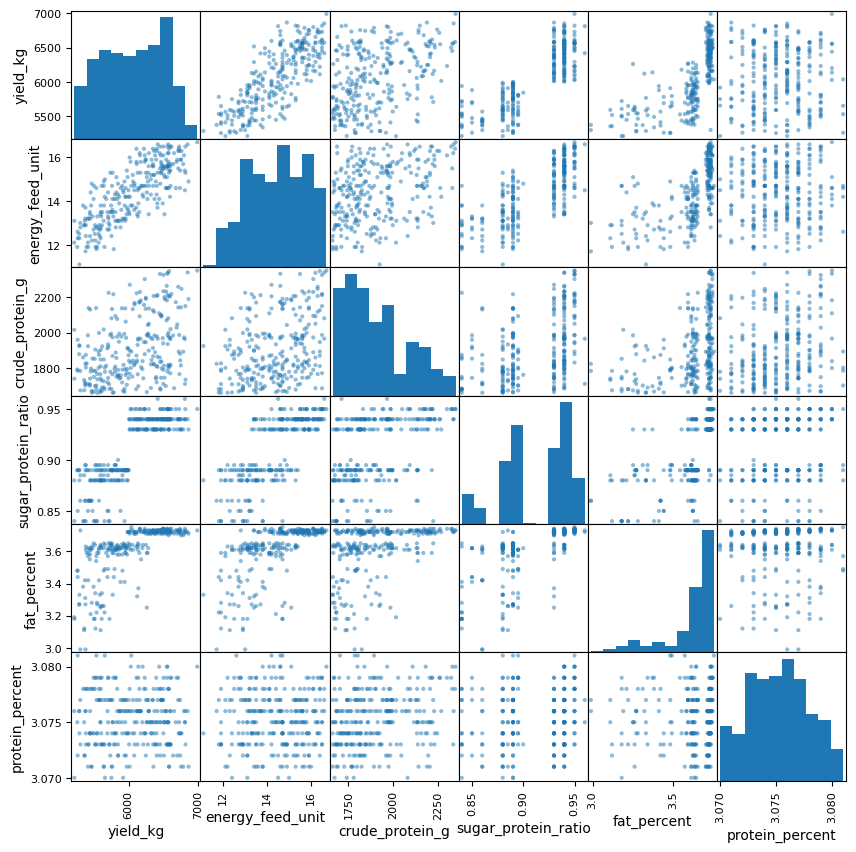

In [1468]:
ferma_main_cat = ferma_main.query('pasture_type=="Равнинное"')[ferma_main_num_features_df['en_name']]
pd.plotting.scatter_matrix(ferma_main_cat, figsize=(10, 10));

<- разделение по типам пастбищ не помогло

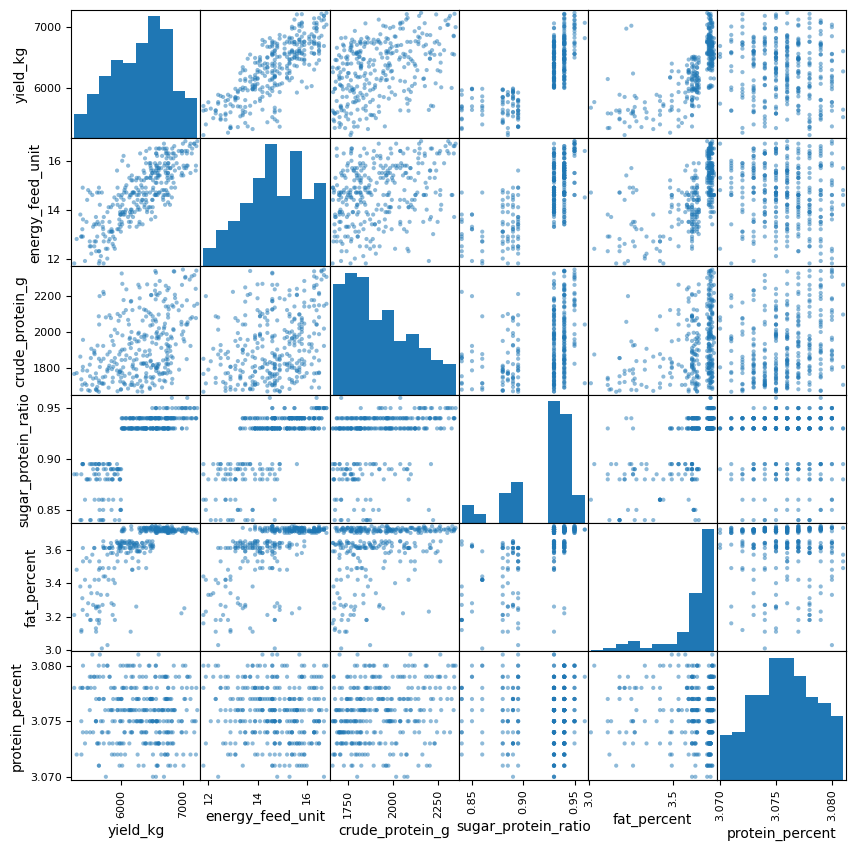

In [1469]:
ferma_main_cat = ferma_main.query('father_breed	=="Айдиал"')[ferma_main_num_features_df['en_name']]
pd.plotting.scatter_matrix(ferma_main_cat, figsize=(10, 10));

<- разделение по породам отцов не помогло

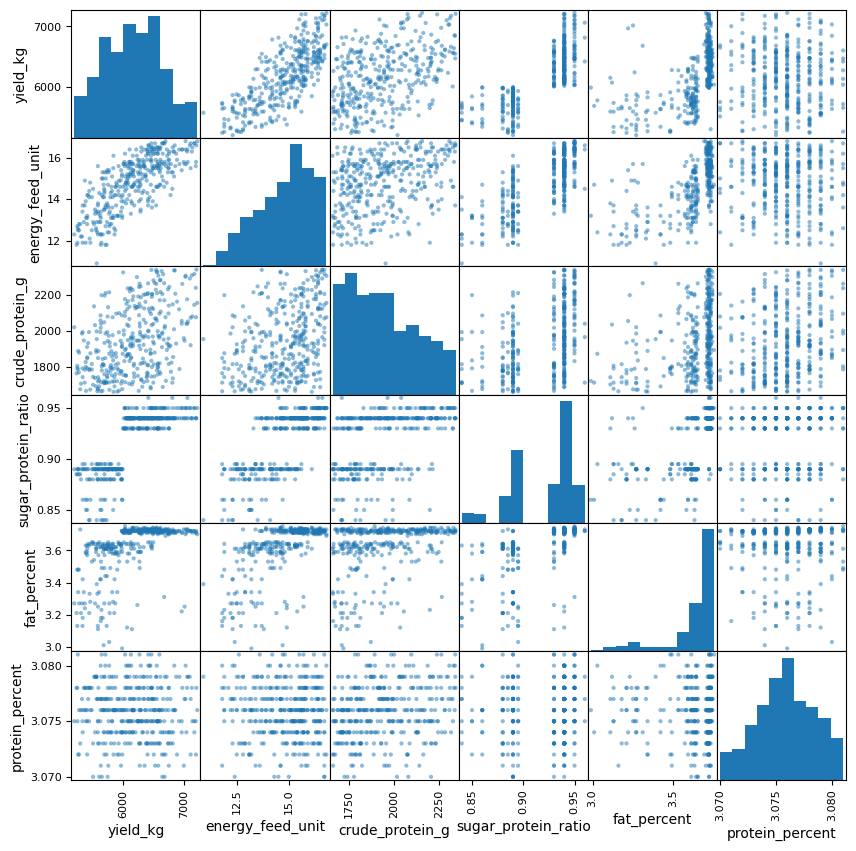

In [1470]:
ferma_main_cat = ferma_main.query('taste_of_milk=="вкусно"')[ferma_main_num_features_df['en_name']]
pd.plotting.scatter_matrix(ferma_main_cat, figsize=(10, 10));

<- разделение по вкусности молока не помогло

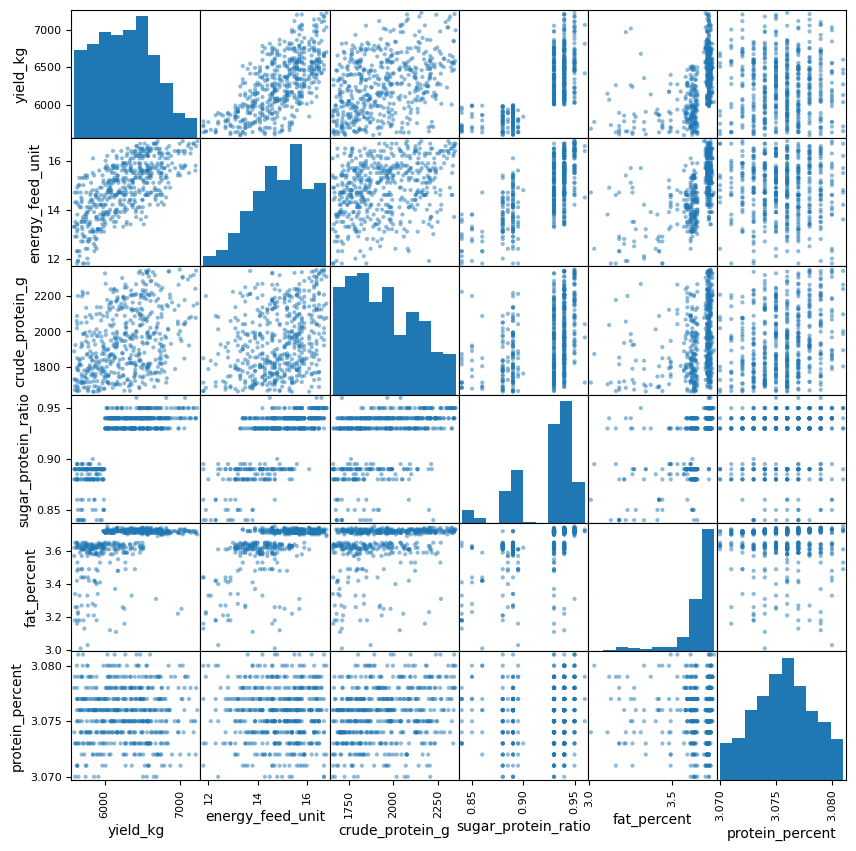

In [1471]:
ferma_main_cat = ferma_main.query('age=="более_2_лет"')[ferma_main_num_features_df['en_name']]
pd.plotting.scatter_matrix(ferma_main_cat, figsize=(10, 10));

<- разделение по возрасту молока не помогло

### Выводы

- Согласно heatmap по phik, наибольшая корреляция выражена между фичами:
    - 0.72, yield_kg - energy_feed_unit
    - 0.72, fat_percent - energy_feed_unit
    - 0.71, yield_kg - fat_percent
    - 0.66, spo - yield_fg

*3.Сделайте выводы о взаимосвязи признаков.* 
- *Какой тип взаимосвязи между целевым и входными признаками?*
    - есть линейная взаимосвязь и корреляция, подтверждённая heatmap scatterplot для фичей Удой и ЭКЕ
- *Есть ли нелинейные связи между целевым и входными признаками? Нужно ли вводить в модель дополнительные признаки, чтобы это учесть?*
    - есть, выявлены подгруппы на scatterplot (например, удой vs СПО), но вычислить закономерность пока что не удалось
- *Наблюдается ли мультиколлинеарность между входными признаками?*
    - найдена сильная взаимосвязь Удой vs ЭКЕ, но она 0.81, и этого недостаточно для удаления ЭКЕ, т. к. в лекциях сказано:
        - *Как правило, о мультиколлинеарности говорят при значении коэффициента корреляции от 0.9 до 0.95 по модулю. В такой ситуации лишние коррелирующие признаки нужно удалять из обучающей выборки.*

## Обучение модели линейной регрессии

1. *Подготовьте данные датасета ferma_main.csv и обучите на них первую модель LinearRegression.*

Признаки, которые могут подойти для обучения модели:
- ЭКЕ (Энергетическая кормовая единица) — показатель питательности корма коровы
    - питание может влиять на размер удоя
    - берём для обучения
- Сырой протеин
    - Сырой протеин — содержание сырого протеина в корме
    - это свойство корма, оно может влиять на удой
    - хотя, корреляция лишь 0.45 (антирекорд в сравнении с другими фичами) - берём для обучения
- СПО (Сахаро-протеиновое соотношение) — отношение сахара к протеину в корме коровы
    - это свойство корма, он может влиять на удой
    - берём для обучения
- ~~Жирность,% — содержание жиров в молоке (в процентах)~~
    - корреляция слабая 0.6, это свойство не "входного" корма, а свойство "выходного" молока, однако может существовать связь с удоем, про которую мы не знаем - что если, например, более жирное молоко выходит медленнее/меньше за один удой?
        - Пожалуйста, поправьте, если неправ, и фичу стоит выкинуть.
    - берём для обучения
- ~~Белок,% — содержание белков в молоке (в процентах)~~
    - корреляция с удоем самая высокая (0.81)
    - берём для обучения
-  оценка вкуса молока по личным критериям фермера, бинарный признак (вкусно, не вкусно).
    - субъективный фактор фермера, на объём удоя он влиять по идее не должен
    - НЕ берём для обучения
- возраст коровы
    - может влиять на объём удоя, можно предположить, что с возрастом молока даёт меньше молока - подтверждается гуглом:
        - Самый благоприятный возраст коров для доение составляет от 4 до 7 лет. Со временем количество молока, которое дает животное существенно снижается. Дело в том, что организм зверя начинает восстанавливаться значительно дольше и эффективность витаминов начинает снижаться.
    - берём для обучения

Тренировка модели:

In [1472]:
def train_and_report (model_name, df, num_col_names, cat_col_names):
    #	Разбейте данные на тренировочную и тестовую выборки.

    X = df.drop('yield_kg', axis=1)
    y = df['yield_kg']
    X_train, X_test, y_train, y_test = train_test_split(
        X, 
        y, 
        random_state=42
    )

    #Кодируйте категориальные признаки с помощью OneHotEncoder:
    
    encoder  = OneHotEncoder(drop='first', sparse=False)
    X_train_ohe = encoder.fit_transform(X_train[cat_col_names])
    X_test_ohe = encoder.transform(X_test[cat_col_names]) 
    encoder_col_names = encoder.get_feature_names() 

    #Масштабируйте количественные признаки с помощью StandardScaler:

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train[num_col_names])
    X_test_scaled = scaler.transform(X_test[num_col_names])

    #Обучите модель линейной регрессии на подготовленных данных:
    X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
    X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)

    X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names)

    X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
    X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)

    model_lr  = LinearRegression()
    model_lr.fit(X_train, y_train)

    predictions = model_lr.predict(X_test)

    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error (y_test, predictions)
    rmse = sqrt(mse)

    display(f"R2 = {r2}")

    #оценим остатки
    residuals = y_test - predictions

    # постройте графики по количественным признакам — гистограмму частотности 
    # распределения и диагm,m,,m,рамму рассеяния
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5))
    axes[0].hist(residuals, bins=33)
    axes[0].set_title('Гистограмма распределения остатков')
    axes[0].set_xlabel('Остатки')

    axes[1].scatter(predictions, residuals)
    axes[1].set_xlabel('Предсказания модели')
    axes[1].set_ylabel('Остатки')
    axes[1].set_title('Анализ дисперсии')
    plt.show()

    lower_quantile = np.quantile(residuals, 0.05)
    upper_quantile = np.quantile(residuals, 0.95)

    return model_lr, predictions, X_train, [model_name, r2, mae, mse, rmse],\
        lower_quantile, upper_quantile, encoder, scaler

'R2 = 0.7832029531509055'

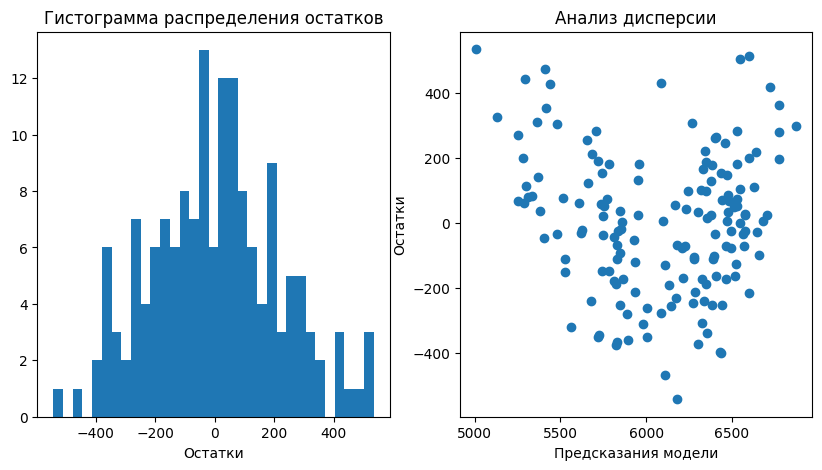

In [1473]:
## убрал жирность и белок
df_1 = ferma_main.drop(['taste_of_milk', 'fat_percent', 'protein_percent'], axis=1)
num_col_names = ['energy_feed_unit',
                'crude_protein_g',
                'sugar_protein_ratio']
cat_col_names = ['breed','pasture_type', 'father_breed', 'age']

model_lr_1, predictions_1, x_1, metrics_1, low_q_1, up_q_1, encoder_1, scaler_1 = \
        train_and_report ("linear-1", df_1, num_col_names, cat_col_names)

 *Выводы по первой регрессионной модели:*
 - *R² модели:*
    - R2 = 0.784
    - Чем ближе метрика к единице, тем лучше обобщающая способность модели и тем точнее будут предсказания. 
    - делаем вывод, что модель обобщает хорошо
- *выводы следуют из анализа остатков:*
    - распределение остатков похоже на нормальное - это хороший знак
    - дисперсия ошибок несколько тяготеет к виду дуги - это не очень хороший знак
- *нужны ли дополнительные исследования:*
    - возможно, поможет исключение нелинейности входных признаков, к которому нас подводит следующее задание...

2.	*Подготовьте данные с учётом связи входных признаков с целевым и обучите на них вторую модель LinearRegression.*

- *СПО и Удой связаны нелинейно. На их диаграмме рассеяния наблюдения сгруппированы в два кластера, причём есть такое значение СПО, которое можно считать границей между кластерами. Чтобы устранить нелинейность, преобразуйте СПО в категориальный бинарный признак, использовав эту границу*

На диаграмме рассеяния выше видно, что зависимость между удоем и СПО представлена в виде кластеров. Кластера можно разделить по значению СПО=0.91. Заменим фичу sugar_protein_ratio на две категориальный бинарный признак:

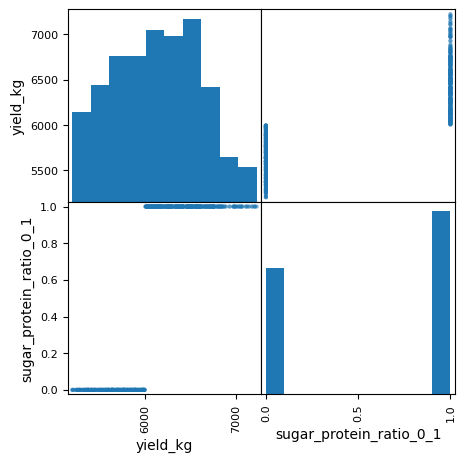

In [1474]:
df_2 = df_1

df_2['sugar_protein_ratio_0_1'] = df_2['sugar_protein_ratio']\
    .apply(lambda x: 0 if x < 0.91 else 1)
df_2 = df_2.drop('sugar_protein_ratio', axis=1)

tmp = df_2[['yield_kg', 'sugar_protein_ratio_0_1']]
pd.plotting.scatter_matrix(tmp, figsize=(5, 5));


Не уверен, это ли ожидалось. Нелинейность не устранена. Всё так же имеем 2 кластера. Можно было бы, наверное, удалить нелинейность, удалив часть данных (т е один из кластеров)... но это явно не то, что нам нужно.

- *ЭКЕ и Удой также связаны нелинейно. Нелинейность между ними можно исключить, если ввести новый признак ЭКЕ в квадрате.*

In [1475]:
df_2['energy_feed_unit'] = df_2['energy_feed_unit']**2

'R2 = 0.8347436421181885'

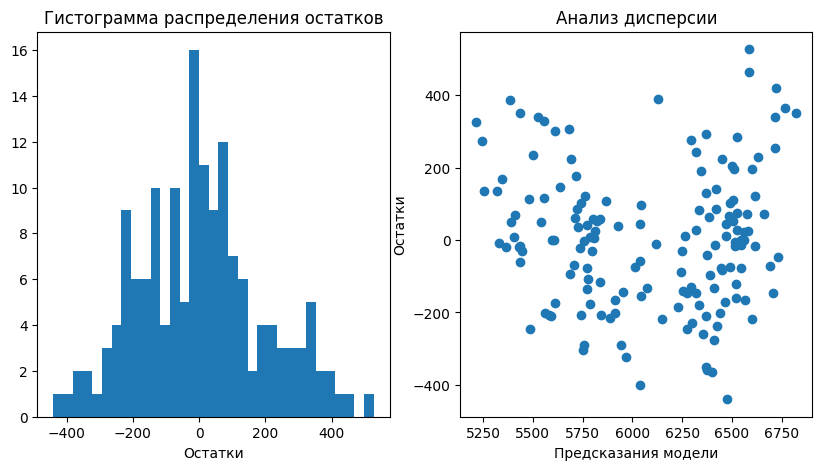

In [1476]:
num_col_names_2 = ['energy_feed_unit',
                'crude_protein_g',
                'sugar_protein_ratio_0_1']

model_lr_2, predictions_2, x_2, metrics_2, low_q_2, up_q_2, encoder_2, scaler_2 = \
    train_and_report ("linear-2", df_2, num_col_names_2, cat_col_names)

~~В задании также сказано, что стоит разбить нелинейную зависимость ЭКЕ и удой - но они как раз у меня почему-то связаны на диаграмме размаха линейно. Что-то не так?~~

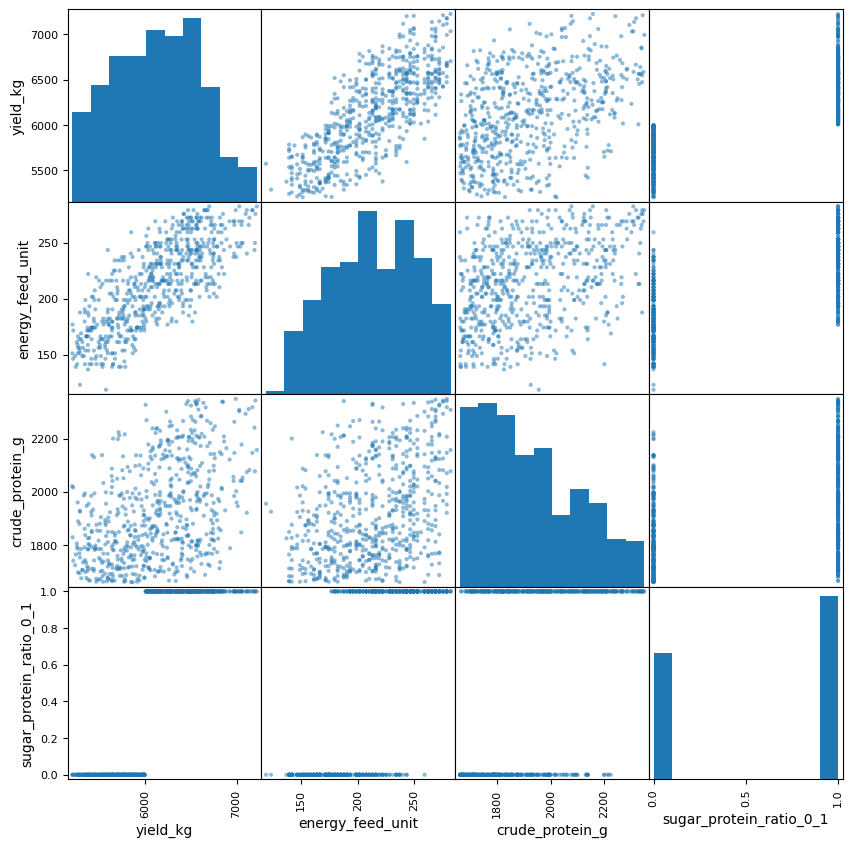

In [1477]:
tmp = df_2
tmp = tmp.drop('id', axis=1)
pd.plotting.scatter_matrix(tmp, figsize=(10, 10));

 *Выводы по второй регрессионной модели:*
 
 - *R² модели:*
    - R2 = 0.818 (лучше, чем у первой модели)
    - Чем ближе метрика к единице, тем лучше обобщающая способность модели и тем точнее будут предсказания.
    - делаем вывод, что модель обобщает хорошо
- *выводы следуют из анализа остатков:*
    - распределение остатков похоже на нормальное  (всё так же) - это хороший знак
    - дисперсия ошибок стала более хаотична - это хороший знак
- *нужны ли дополнительные исследования:*
    - возможно, поможет добавление признака Имя Папы, к которому нас подводит следующее задание...


3.	*Добавьте в данные новый признак и обучите на них третью модель LinearRegression.*

In [1478]:
df_3 = df_2
df_3.shape

(623, 9)

In [1479]:
df_3 = df_3.merge(ferma_dad, on='id', how='left')
df_3 = df_3.reset_index()
display(df_3.shape)
display(df_3.head())

(623, 11)

,index,id,yield_kg,energy_feed_unit,crude_protein_g,breed,pasture_type,father_breed,age,sugar_protein_ratio_0_1,father_name
0,0,1,5863,201.64,1743,Вис Бик Айдиал,Равнинное,Айдиал,более_2_лет,0,Буйный
1,1,2,5529,163.84,2138,Вис Бик Айдиал,Равнинное,Соверин,менее_2_лет,0,Соловчик
2,2,3,5810,196.00,1854,РефлешнСоверинг,Холмистое,Соверин,более_2_лет,0,Барин
3,3,4,5895,153.76,2012,РефлешнСоверинг,Холмистое,Айдиал,более_2_лет,0,Буйный
4,4,5,5302,163.84,1675,Вис Бик Айдиал,Равнинное,Соверин,менее_2_лет,0,Барин


'R2 = 0.8347436421181885'

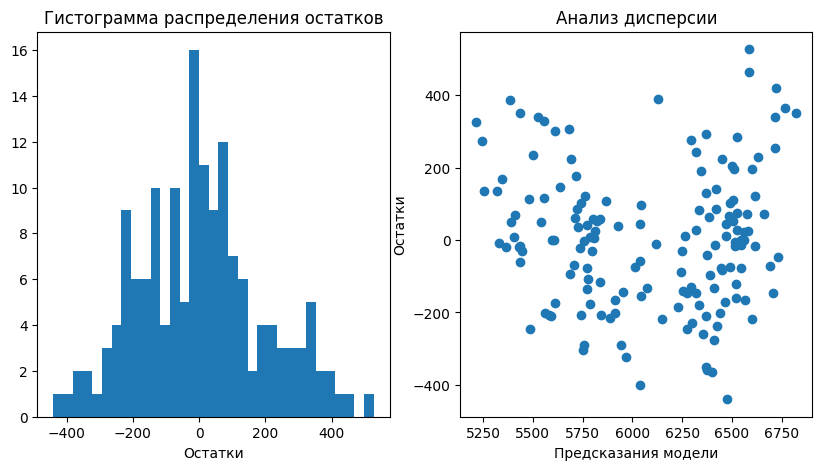

In [1480]:
model_lr_3, predictions_3, x_3, metrics_3, low_q_3, up_q_3, encoder_3, scaler_3 = \
    train_and_report ("linear-3", df_3, num_col_names_2, cat_col_names)

 *Выводы по третьей регрессионной модели:*

 - *R² модели:*
    - R2 = 0.818
    - Чем ближе метрика к единице, тем лучше обобщающая способность модели и тем точнее будут предсказания. 
    - делаем вывод, что модель обобщает хорошо
- *выводы следуют из анализа остатков:*
    - распределение остатков похоже на нормальное - это хороший знак
    - дисперсия ошибок несколько тяготеет к виду дуги - это не очень хороший знак
- *нужны ли дополнительные исследования:*
    - не понятно - видимо, что-то я делаю не так (надеюсь, ревьюер подскажет, что именно) - все графики одинаковые, хотя у последней модели R2 лучше, чем у первой.


4.	*Сравните качество трёх моделей линейной регрессии, сопоставьте их R² и остатки.*

In [1481]:
metrics_linear = pd.DataFrame([metrics_1, metrics_2, metrics_3], 
                       columns=['model_name', 'r2', 'mae', 'mse', 'rmse']) \
                       .set_index('model_name')
display(metrics_linear['r2'])

model_name
linear-1    0.783203
linear-2    0.834744
linear-3    0.834744
Name: r2, dtype: float64

Выиграла 2я и 3я модель, но допускаю, что сделал что-то не то, т. к. нет улучшения на третьей модели. А также не удалось избавиться от кластеров/нелинейности удой-СПО. Не выявилось нелинейности удой-ЭКЕ (хотя в задании утверждается, что она должна была бы быть). Как сравнить остатки кроме как по графикам, не очень понимаю, но графики остатков очень похожи.

5.	*Оцените качество каждой модели по трём метрикам: MSE, MAE, RMSE.*

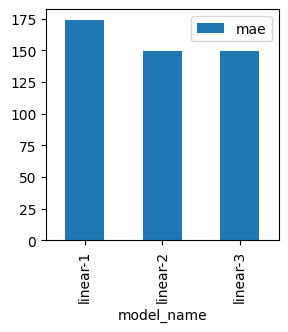

In [1482]:
metrics_linear.plot(kind='bar', y='mae', figsize=(3,3));

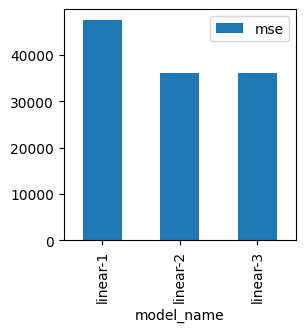

In [1483]:
metrics_linear.plot(kind='bar', y='mse', figsize=(3,3));

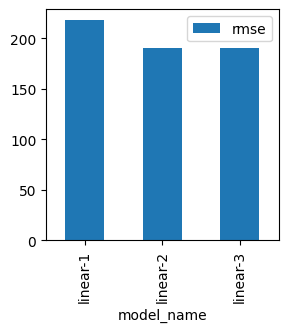

In [1484]:
metrics_linear.plot(kind='bar', y='rmse', figsize=(3,3));

In [1485]:
display(metrics_linear)

,r2,mae,mse,rmse
model_name,,,,
linear-1,0.783203,173.801223,47499.999455,217.944946
linear-2,0.834744,149.719800,36207.490016,190.282658
linear-3,0.834744,149.719800,36207.490016,190.282658


По всем трём метрикам у 2й и 3й модели показатели одинаковые, и они лучше, чем у 3й модели.

*Выберите лучшую модель;*

Выбираю третью модель, т. к. у нее лучше R2 и она более полна (содержит имена пап коров)

*Укажите доверительный интервал прогноза лучшей модели. Для этого рассчитайте квантили ошибки модели на тренировочных данных.*

Доверительный интервал мы не проходили в лекциях (и в задаче не указан требуемый уровень значимости, возьмём его за 0.05). Нашёл в интернете и добавил в функцию:

In [1486]:
display(f"Доверительный интервал прогноза: [{low_q_3}, {up_q_3}]")

'Доверительный интервал прогноза: [-289.84448986981647, 341.283907016234]'

6.	*С помощью лучшей модели спрогнозируйте удой коров, которых фермер хочет купить.*
- *Добавьте недостающие признаки ЭКЕ (Энергетическая кормовая единица), Сырой протеин, г и СПО (Сахаро-протеиновое соотношение): возьмите из датасета ferma_main.csv средние значения каждого из признаков и увеличьте их на 5%.*

Кстати, интересно, зачем увеличиваем на 5%?

In [1487]:
energy_feed_unit_1_05_avg = ferma_main['energy_feed_unit'].mean()*1.05
crude_protein_g_1_05_avg = ferma_main['crude_protein_g'].mean()*1.05
sugar_protein_ratio_1_05_avg = ferma_main['sugar_protein_ratio'].mean()*1.05

In [1488]:
cow_buy['energy_feed_unit'] = energy_feed_unit_1_05_avg
cow_buy['crude_protein_g'] = crude_protein_g_1_05_avg
cow_buy['sugar_protein_ratio'] = sugar_protein_ratio_1_05_avg

display(cow_buy.info())
display(cow_buy.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   breed                20 non-null     object 
 1   pasture_type         20 non-null     object 
 2   father_breed         20 non-null     object 
 3   father_name          20 non-null     object 
 4   fat_percent          20 non-null     float64
 5   protein_percent      20 non-null     float64
 6   age                  20 non-null     object 
 7   energy_feed_unit     20 non-null     float64
 8   crude_protein_g      20 non-null     float64
 9   sugar_protein_ratio  20 non-null     float64
dtypes: float64(5), object(5)
memory usage: 1.7+ KB


None

,breed,pasture_type,father_breed,father_name,fat_percent,protein_percent,age,energy_feed_unit,crude_protein_g,sugar_protein_ratio
0,Вис Бик Айдиал,Равнинное,Айдиал,Геркулес,3.58,3.076,более_2_лет,15.276742,2019.77191,0.958947
1,Вис Бик Айдиал,Равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет,15.276742,2019.77191,0.958947
2,РефлешнСоверинг,Холмистое,Соверин,Барин,3.59,3.074,более_2_лет,15.276742,2019.77191,0.958947
3,РефлешнСоверинг,Холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет,15.276742,2019.77191,0.958947
4,РефлешнСоверинг,Равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет,15.276742,2019.77191,0.958947


- *Выполните подготовку данных, аналогичную той, которую делали для тренировочной выборки.*


In [1489]:
cow_buy_lr3 = cow_buy
cow_buy_lr3['sugar_protein_ratio_0_1'] = cow_buy_lr3['sugar_protein_ratio']\
    .apply(lambda x: 0 if x < 0.91 else 1)
cow_buy_lr3 = cow_buy_lr3.drop('sugar_protein_ratio', axis=1)
##2 добавил возведение в квадрат:
cow_buy_lr3['energy_feed_unit'] = cow_buy_lr3['energy_feed_unit']**2

#Кодируйте категориальные признаки с помощью OneHotEncoder:
X_test_ohe = encoder_3.transform(cow_buy_lr3[cat_col_names]) 
encoder_col_names = encoder_3.get_feature_names() 

#Масштабируйте количественные признаки с помощью StandardScaler:

scaler = StandardScaler()
X_test_scaled = scaler_3.transform(cow_buy_lr3[num_col_names_2])

X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)

X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names_2)

X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)

- *Получите прогноз удоя коров.*

In [1490]:
predictions_inference = model_lr_3.predict(X_test)

Прогноз удоя - в таблице ниже

In [1491]:
result_lr_3 = X_test
result_lr_3 ['predicted_yield_kg'] = predictions_inference
display('prediction results:', result_lr_3)

'prediction results:'

,x0_РефлешнСоверинг,x1_Холмистое,x2_Соверин,x3_менее_2_лет,energy_feed_unit,crude_protein_g,sugar_protein_ratio_0_1,predicted_yield_kg
0,0.0,0.0,0.0,0.0,0.495804,0.498407,0.791946,6506.992437
1,0.0,0.0,1.0,1.0,0.495804,0.498407,0.791946,6061.096583
2,1.0,1.0,1.0,0.0,0.495804,0.498407,0.791946,6343.559577
3,1.0,1.0,0.0,0.0,0.495804,0.498407,0.791946,6562.690252
4,1.0,0.0,0.0,0.0,0.495804,0.498407,0.791946,6525.146015
5,1.0,1.0,1.0,1.0,0.495804,0.498407,0.791946,6116.794398
6,0.0,0.0,0.0,0.0,0.495804,0.498407,0.791946,6506.992437
7,0.0,0.0,1.0,0.0,0.495804,0.498407,0.791946,6287.861762
8,1.0,1.0,1.0,0.0,0.495804,0.498407,0.791946,6343.559577
9,1.0,1.0,0.0,1.0,0.495804,0.498407,0.791946,6335.925073


In [1492]:
result_lr_3 ['predicted_yield_kg'].mean()

6351.333747265233

### Выводы
- Наилучшие показатели показала модель-2 и модель-3
- модель прогнозирует на тестовой выборке средний удой в 5462 кг

## Обучение модели логистической регрессии

*Подготовьте данные датасета ferma_main.csv и обучите на них модель LogisticRegression.*

- *Используйте в качестве целевого признак Вкус молока.*


In [1493]:
df = ferma_main

X = df.drop('taste_of_milk', axis=1)
y = df['taste_of_milk'].apply(lambda x: 1 if x == 'вкусно' else 0)

In [1494]:
X['energy_feed_unit'] = X['energy_feed_unit']**2

- *При необходимости преобразуйте имеющиеся или добавьте новые признаки.*


- *Разбейте данные на тренировочную и тестовую выборки.*


In [1495]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    random_state=42
)

- *Кодируйте категориальные признаки с помощью OneHotEncoder.*


In [1496]:
encoder  = OneHotEncoder(drop='first', sparse=False)
X_train_ohe = encoder.fit_transform(X_train[cat_col_names])
X_test_ohe = encoder.transform(X_test[cat_col_names]) 
encoder_col_names = encoder.get_feature_names()

- *Масштабируйте количественные признаки с помощью StandardScaler.*


In [1497]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[num_col_names])
X_test_scaled = scaler.transform(X_test[num_col_names])

- *Обучите модель логистической регрессии на подготовленных данных.*


In [1498]:
X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names)

X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)

clf  = LogisticRegression()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

- *Оцените качество модели на тестовой выборке: рассчитайте метрики accuracy, recall, precision.*


In [1499]:
recall = recall_score (y_test, y_pred, pos_label=1)
precision = precision_score(y_test, y_pred, pos_label=1)

display('recall: ',round(recall ,3))
display('precision: ',round(precision,3))

'recall: '

0.759

'precision: '

0.623

- *Постройте матрицу ошибок.*

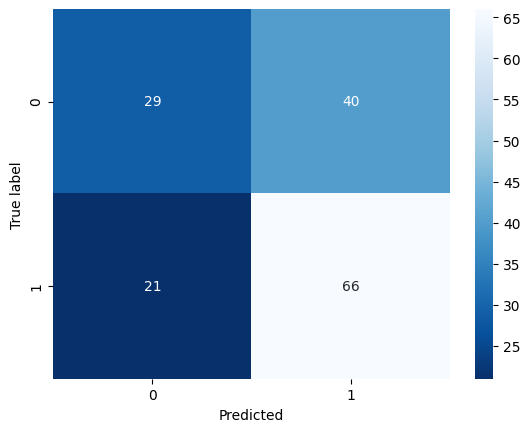

In [1500]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r')
plt.ylabel('True label')
plt.xlabel('Predicted'); 

2.	*Проанализируйте модель логистической регрессии*

*Объясните, какая ошибка критичнее всего при покупке коров: первого или второго рода. Помните, что главное для заказчика — вкусное молоко. Сформулируйте ответ с учётом метрик recall и precision, выберите более важную из них.*

Важнее precision, т. к. важно вкусное молоко, а значит нежелательно невкусное молоко признать вкусным (FP, ошибка 1 рода).

*Сведите критичную ошибку к нулю: для этого измените порог принадлежности к классам. Ещё раз рассчитайте значения метрик recall и precision. Какое значение порога вы выбрали? Как изменились значения метрик?*

Я посмотрел соответствующую лекцию "Спринт 10/32 → Тема 8/11: Метрики в задаче классификации → Урок 5/7 Порог классификации" - и там нет кода, который это делает. Не пропущен ли он авторами куса?

Я сделал его по наитию, но работать он будет для требования precision=0. Нужно тут пояснения ревьюера - как это делать в общем случае. К тому же не понятно, как в обученной модели менять порог? Это нужно для новых предиктов. Пока придётся снова делать какие-то костыли. Жду помощи ревьюера.

In [1501]:
y_proba = clf.predict_proba(X_test)[:,1]

data = pd.DataFrame(zip(y_test, y_proba),
             columns = ['y_valid', 'y_proba']).sort_values(by='y_proba',ascending=False)

thresholds = [round(i,2) for i in np.linspace(0.1,1,num = 100,endpoint=False)]

columns = []
thresh_prec_rec = []

for i in thresholds:
	columns.append('y_pred_'+str(i))
	threshold = 'y_pred_'+str(i)
	data[threshold] = data['y_proba'].apply(lambda x: 1 if x >= i else 0)
	precision = precision_score(y_test, data[threshold], pos_label=1)
	recall = recall_score (y_test, data[threshold], pos_label=1)	
	thresh_prec_rec.append([threshold, precision, recall])

thresh_prec_rec = pd.DataFrame(thresh_prec_rec, columns=['threashhold', 
														 'precision', 'recall'])
display(data)
display(thresh_prec_rec.query('precision >= 0.8'))

c:\Users\Papa\anaconda3\envs\practicum\lib\site-packages\sklearn\metrics\_classification.py:1245: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Papa\anaconda3\envs\practicum\lib\site-packages\sklearn\metrics\_classification.py:1245: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Papa\anaconda3\envs\practicum\lib\site-packages\sklearn\metrics\_classification.py:1245: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Papa\anaconda3\envs\practicum\lib\site-packages\sklearn\metrics\_cl

,y_valid,y_proba,y_pred_0.1,y_pred_0.11,y_pred_0.12,y_pred_0.13,y_pred_0.14,y_pred_0.15,y_pred_0.16,y_pred_0.17,...,y_pred_0.9,y_pred_0.91,y_pred_0.92,y_pred_0.93,y_pred_0.94,y_pred_0.95,y_pred_0.96,y_pred_0.97,y_pred_0.98,y_pred_0.99
142,1,0.836444,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
32,1,0.813835,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,1,0.805457,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
26,1,0.803899,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
58,1,0.800367,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,0,0.336333,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
125,0,0.317986,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,0,0.311805,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
123,1,0.310176,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


,threashhold,precision,recall
80,y_pred_0.82,1.0,0.011494
81,y_pred_0.83,1.0,0.011494


Порог 0.81 даёт нам идеальный precision=1 но из 100 хороших коров отфильтрует а 97.У нас может не быть так много коров на выбор.

Поэтому выбираю порог 0.74 - он даёт второй по величине precision (0.85) и самый высокий recall c приемлимым (>=0.8) precision.

In [1502]:
LGR_THRESHOLD = 0.74

In [1503]:
"""TPs = len(data.query('y_valid == 1 and y_proba >= 0.78'))
FNs = len(data.query('y_valid == 1 and y_proba < 0.78'))
recall = TPs/(TPs+FNs)
display(f"recall={recall}")"""

'TPs = len(data.query(\'y_valid == 1 and y_proba >= 0.78\'))\nFNs = len(data.query(\'y_valid == 1 and y_proba < 0.78\'))\nrecall = TPs/(TPs+FNs)\ndisplay(f"recall={recall}")'

### Выводы

*Оформите выводы: скажите, что нужно сделать дальше, исходя из анализа модели?*

- По условиям задачи критичнее Precision
- Перебрано несколько порогов и оптимальным выбран порог 0.74 - он даёт второй по величине precision (0.85) и самый высокий recall c приемлимым (>=0.8 precision).

3.	*С помощью обученной модели спрогнозируйте вкус молока коров, которых фермер хочет купить*

*Выполните подготовку данных, аналогичную той, которую делали для тренировочной выборки.*


In [1504]:
cow_buy_2 = cow_buy
cow_buy_2['energy_feed_unit'] = cow_buy_2['energy_feed_unit']**2
#cow_buy_2['sugar_protein_ratio_0_1'] = cow_buy_2['sugar_protein_ratio']\
#    .apply(lambda x: 0 if x < 0.91 else 1)
#cow_buy_2 = cow_buy_2.drop('sugar_protein_ratio', axis=1)

In [1505]:
X_inf_ohe = encoder.transform(cow_buy_2[cat_col_names]) 
encoder_col_names = encoder.get_feature_names() 

X_inf_scaled = scaler.transform(cow_buy_2[num_col_names_2])

X_inf_ohe = pd.DataFrame(X_inf_ohe, columns=encoder_col_names)

X_inf_scaled = pd.DataFrame(X_inf_scaled, columns=num_col_names)

X_inf = pd.concat([X_inf_ohe, X_inf_scaled], axis=1)


*Получите прогноз вкуса молока коров.*

In [1506]:
"""predictions_proba = clf.predict_proba(X_inf)[:,1]
result_lgr = cow_buy
result_lgr['predictions_proba'] = predictions_proba
result_lgr['predicted_tasty_milk'] = result_lgr['predictions_proba'] \
    .apply(lambda x: 1 if x >= LGR_THRESHOLD else 0)"""

result_lgr = cow_buy
result_lgr['predicted_tasty_milk'] = clf.predict_proba(X_inf)[:,1] > LGR_THRESHOLD
display(result_lgr)

,breed,pasture_type,father_breed,father_name,fat_percent,protein_percent,age,energy_feed_unit,crude_protein_g,sugar_protein_ratio,sugar_protein_ratio_0_1,predicted_tasty_milk
0,Вис Бик Айдиал,Равнинное,Айдиал,Геркулес,3.58,3.076,более_2_лет,233.378833,2019.77191,0.958947,1,False
1,Вис Бик Айдиал,Равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет,233.378833,2019.77191,0.958947,1,False
2,РефлешнСоверинг,Холмистое,Соверин,Барин,3.59,3.074,более_2_лет,233.378833,2019.77191,0.958947,1,True
3,РефлешнСоверинг,Холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет,233.378833,2019.77191,0.958947,1,True
4,РефлешнСоверинг,Равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет,233.378833,2019.77191,0.958947,1,False
5,РефлешнСоверинг,Холмистое,Соверин,Геркулес,3.63,3.053,менее_2_лет,233.378833,2019.77191,0.958947,1,True
6,Вис Бик Айдиал,Равнинное,Айдиал,Геркулес,3.58,3.076,более_2_лет,233.378833,2019.77191,0.958947,1,False
7,Вис Бик Айдиал,Равнинное,Соверин,Буйный,3.57,3.079,более_2_лет,233.378833,2019.77191,0.958947,1,False
8,РефлешнСоверинг,Холмистое,Соверин,Барин,3.59,3.074,более_2_лет,233.378833,2019.77191,0.958947,1,True
9,РефлешнСоверинг,Холмистое,Айдиал,Буйный,3.40,3.079,менее_2_лет,233.378833,2019.77191,0.958947,1,True


## Итоговые выводы

*Добавьте прогнозы вкуса молока и удоя коров «ЭкоФермы» в датафрейм с коровами, покупку которых рассматривает фермер.*

In [1507]:
cow_buy ['predicted_yield_kg'] = result_lr_3['predicted_yield_kg']
cow_buy ['predicted_tasty_milk'] = result_lgr['predicted_tasty_milk']
display(cow_buy)

,breed,pasture_type,father_breed,father_name,fat_percent,protein_percent,age,energy_feed_unit,crude_protein_g,sugar_protein_ratio,sugar_protein_ratio_0_1,predicted_tasty_milk,predicted_yield_kg
0,Вис Бик Айдиал,Равнинное,Айдиал,Геркулес,3.58,3.076,более_2_лет,233.378833,2019.77191,0.958947,1,False,6506.992437
1,Вис Бик Айдиал,Равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет,233.378833,2019.77191,0.958947,1,False,6061.096583
2,РефлешнСоверинг,Холмистое,Соверин,Барин,3.59,3.074,более_2_лет,233.378833,2019.77191,0.958947,1,True,6343.559577
3,РефлешнСоверинг,Холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет,233.378833,2019.77191,0.958947,1,True,6562.690252
4,РефлешнСоверинг,Равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет,233.378833,2019.77191,0.958947,1,False,6525.146015
5,РефлешнСоверинг,Холмистое,Соверин,Геркулес,3.63,3.053,менее_2_лет,233.378833,2019.77191,0.958947,1,True,6116.794398
6,Вис Бик Айдиал,Равнинное,Айдиал,Геркулес,3.58,3.076,более_2_лет,233.378833,2019.77191,0.958947,1,False,6506.992437
7,Вис Бик Айдиал,Равнинное,Соверин,Буйный,3.57,3.079,более_2_лет,233.378833,2019.77191,0.958947,1,False,6287.861762
8,РефлешнСоверинг,Холмистое,Соверин,Барин,3.59,3.074,более_2_лет,233.378833,2019.77191,0.958947,1,True,6343.559577
9,РефлешнСоверинг,Холмистое,Айдиал,Буйный,3.40,3.079,менее_2_лет,233.378833,2019.77191,0.958947,1,True,6335.925073


In [1508]:
cow_buy ['predicted_yield_kg'].mean()

6351.333747265233

*Отберите коров, для которых спрогнозирован удой более 6000 килограммов в год и вкусное молоко.*

In [1512]:
good_cows = cow_buy.query('predicted_yield_kg >= 6000 and predicted_tasty_milk == 1')
display(len(good_cows))

12

*Коротко опишите результаты работы моделей для фермера.* 
- *Сколько коров он может купить из стада на продажу с минимальным риском для себя? Почему?*
    - 12 коров ихз таблицы выше - т. к. вкус молока должен понравиться фермеру и удой будет больше 6000, согласно предсказаниям модели
- *Какие ещё рекомендации можно ему дать?*
    - Средний удой коров ЭкоФермы, согласно предсказанию модели, составит 5462. Можно снизить ожидания по удою, либо поискать другие фермы.
    - для повышения качества модели:
        - стоит увеличить размер датасета ferma_main
        - можно увеличить количество фичей датасета ferma_main


*Сделайте выводы о моделях линейной регрессии и логистической регрессии.* 
- *Какие способы улучшения качества регрессионной модели вы использовали в этой задаче?*
    - проведена предобработка данных (удалены явные и неявные дубликаты)
    - удалена корова с аномальным удоем в 40 тонн
    - проведён корреляционный анализ, выявлена наибольшая зависимость между фичами удой, ЭКЕ, СПО, жирность
    - проведён отбор фичей (не взяты в Жирность, Белок, Вкус)
    - учтена нелинейность СПО (2 кластера вокруг значения 0.91), а также параболичность ЭКЕ устранена возведением ЭКЕ в квадрат
- *Возможно ли ещё улучшить результаты регрессионной модели? Если можно, то как? Если нет, то почему?*
    - R2 = 0.818, что неплохо
    - доверительный интервал прогноза удоя [-303;311]
    - улучшить модель, вероятно, можно было бы, увеличив размер датасета
  - *Какие метрики моделей классификации, в том числе логистической регрессии, важны при анализе рисков или экономических расчётов?*
    - важны precision, recall - что важнее, определяется приоритетами бинеса, в данной задаче - приоритетен Precision
    - для выбранного оптимального порога классификации в 0.74 полученные Precision = 0.85, Recall = 0.25
    - Recall очень низкий (из 100 коров со вкусным молоком, 75 коров мы ошибочно не купим)
      - улучшать recall можно увеличением датасета и расширением состава репрезентативных фичей, а также, вероятно, более продвинутыми методами оптимизации моделей и/или заменой их архитектур
